# EDA - Exploratory Data Analysis

Comprehensive exploration of the Kaggle *Fake and Real News* dataset.  
Goal: understand the data characteristics and motivate every preprocessing decision in `02_preprocessing.ipynb`.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import mannwhitneyu
import re

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from wordcloud import WordCloud

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

LABEL_NAMES = {0: "Fake", 1: "Real"}
LABEL_COLORS = {0: "#e74c3c", 1: "#2ecc71"}

/Users/aoleszkiewicz/dev/factlens/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load raw data from Kaggle

In [2]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

In [3]:
true_df = pd.read_csv(f"{path}/True.csv")
fake_df = pd.read_csv(f"{path}/Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

news_df = pd.concat([true_df, fake_df], ignore_index=True)
print(f"True articles: {len(true_df):,}")
print(f"Fake articles: {len(fake_df):,}")
print(f"Total: {len(news_df):,}")

True articles: 21,417
Fake articles: 23,481
Total: 44,898


## 1. Data Overview

In [4]:
print(f"Shape: {news_df.shape}")
print(f"\nColumns: {list(news_df.columns)}")
print()
news_df.info()

Shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [5]:
news_df.describe(include="all")

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [7]:
pd.set_option("display.max_colwidth", 200)

print("Sample REAL articles:")
display(news_df[news_df["label"] == 1].sample(6, random_state=42))

print("\nSample FAKE articles:")
display(news_df[news_df["label"] == 0].sample(6, random_state=42))

Sample REAL articles:


,title,text,subject,date,label
18137,Europe rights watchdog says Turkey's emergency laws go too far,BRUSSELS (Reuters) - A leading European rights watchdog called on Turkey on Friday to ease post-coup state of emergency laws that have seen thousands arrested and restore power to regional authori...,worldnews,"October 6, 2017",1
3277,Exclusive: Trump targets illegal immigrants who were given reprieves from deportation by Obama,"(Reuters) - In September 2014, Gilberto Velasquez, a 38-year-old house painter from El Salvador, received life-changing news: The U.S. government had decided to shelve its deportation action again...",politicsNews,"June 9, 2017",1
2876,"At G20 summit, Trump pledges $639 million in aid to four countries","HAMBURG (Reuters) - U.S. President Donald Trump on Saturday promised $639 million in aid to feed people left starving because of drought and conflict in Somalia, South Sudan, Nigeria and Yemen. Tr...",politicsNews,"July 8, 2017",1
5160,Ex-Christie associates lose bid for new trial in 'Bridgegate' case,NEW YORK (Reuters) - A federal judge rejected a request for a new trial by two former associates of New Jersey Governor Chris Christie who were convicted for their roles in the “Bridgegate” lane c...,politicsNews,"March 2, 2017",1
10843,Young blacks more open to Bernie Sanders' White House bid,"ORANGEBURG, S.C. (Reuters) - If Democratic hopeful Bernie Sanders has a chance of drawing African-American voters away from rival Hillary Clinton in South Carolina’s presidential nominating contes...",politicsNews,"February 12, 2016",1
2725,New York attorney general says will sue over Obamacare repeal,"(Reuters) - New York state Attorney General Eric Schneiderman intends to sue the federal government if Republican lawmakers pass proposed legislation to overhaul the U.S. healthcare system, his of...",politicsNews,"July 17, 2017",1



Sample FAKE articles:


,title,text,subject,date,label
34891,ABOUT HILLARY’S COUGH: We Discovered The Secret To Why She Keeps Coughing [Video],,politics,"Jul 20, 2016",0
33411,BREAKING: OBAMACARE REPEAL Clears First Hurdle…Dems Get Snarky,"The Senate voted 51-48 this afternoon to proceed to the resolution, S. Con. Res. 3, which would set up a filibuster-proof process, ensuring the chamber s consideration of legislation repealing par...",politics,"Jan 4, 2017",0
40596,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Saying She’d Back Abolition Of The Electoral College [Video],So much for the SCOTUS not being political Check out her comments on equality for women. It s like she s time traveled back to the 50 s. What is the deal with these women that think we re still in...,left-news,"Feb 7, 2017",0
21918,WATCH: Kellyanne Conway Very Upset Hillary Clinton Is Not Doing Trump’s Job,White House counselor Kellyanne Conway crawled out of her crypt after two weeks in hiding to attack Hillary Clinton who is totally not the President. Former reality show star Donald Trump was swor...,News,"August 24, 2017",0
24909,"GOP Gives Trump The Middle Finger, Prepares To Launch Probe Into Russia","Donald Trump may have decided that Russia is going to be America s new BFF, but the rest of the GOP isn t so sure. Going against the incoming administration, several Republicans are preparing to l...",News,"December 9, 2016",0
22927,Trump Displays Incredible Ignorance Yet Again — Claims Credit For Term Coined Over A Hundred Years Ago,Have you ever wondered where a phrase started? How about the phrase prime the pump? It is widely considered to mean the use of government money to get a project going. While it dates back to the...,News,"May 11, 2017",0


## 2. Metadata Exploration (title, subject, date)

Before dropping these columns, let's explore what they contain and why they shouldn't be used as model features.

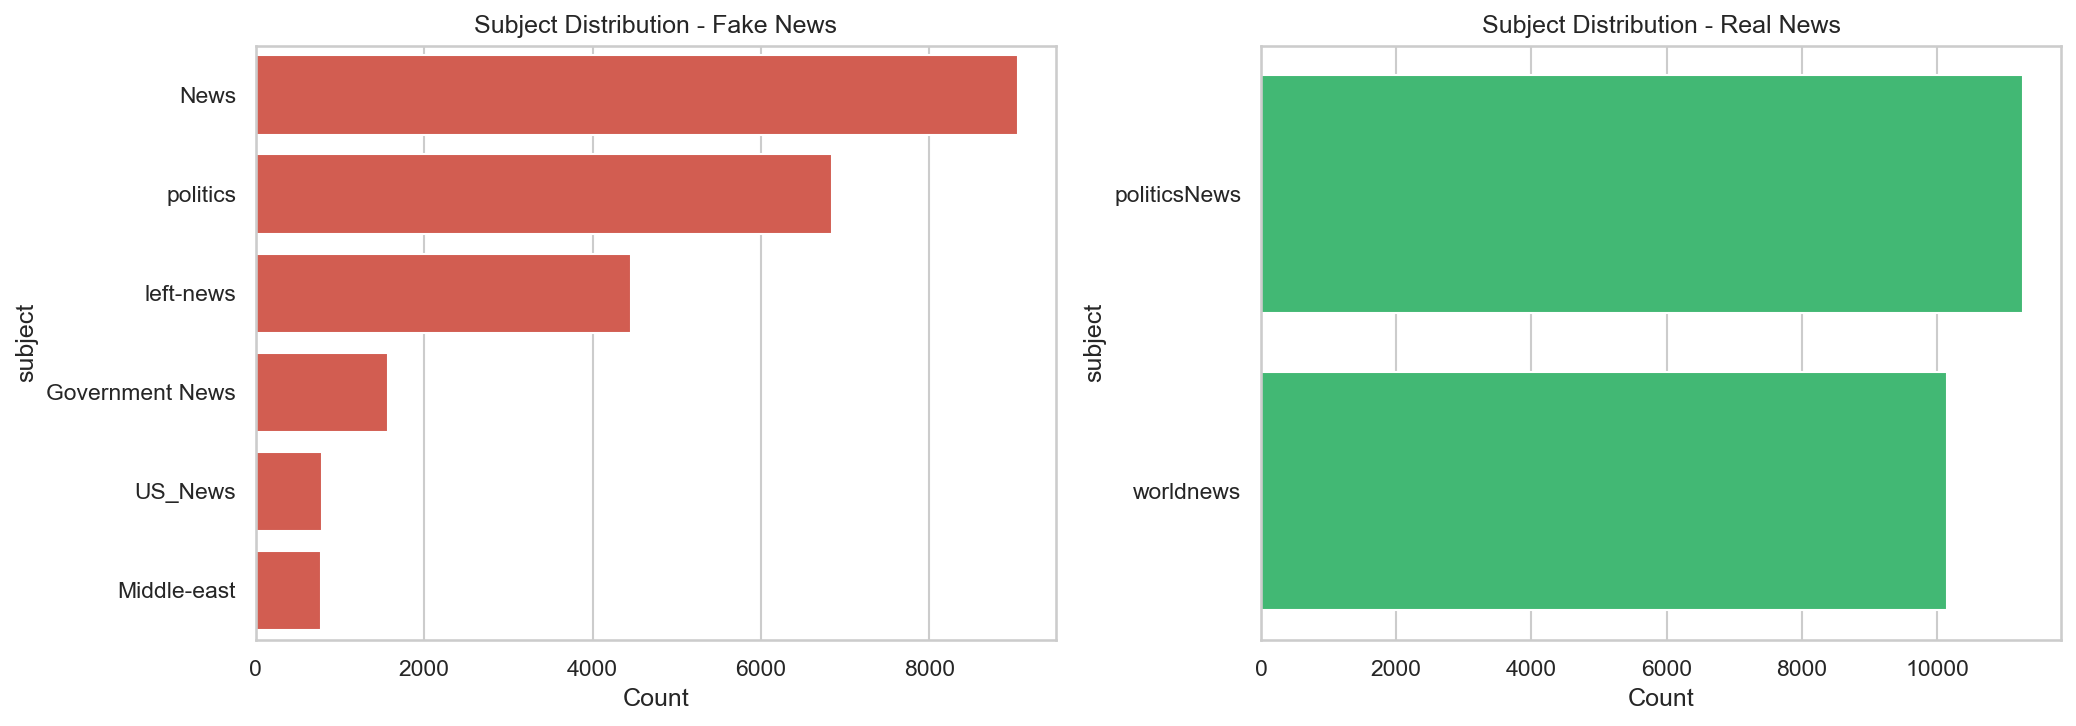

Subject counts by class:
label  subject        
0      News                9050
       politics            6841
       left-news           4459
       Government News     1570
       US_News              783
       Middle-east          778
1      politicsNews       11272
       worldnews          10145
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, name) in zip(axes, LABEL_NAMES.items()):
    subset = news_df[news_df["label"] == label]
    order = subset["subject"].value_counts().index
    sns.countplot(data=subset, y="subject", order=order, ax=ax, color=LABEL_COLORS[label])
    ax.set_title(f"Subject Distribution - {name} News")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

print("Subject counts by class:")
print(news_df.groupby("label")["subject"].value_counts())

Unparseable dates: 23481
Date range: 2016-01-13 00:00:00 to 2017-12-31 00:00:00


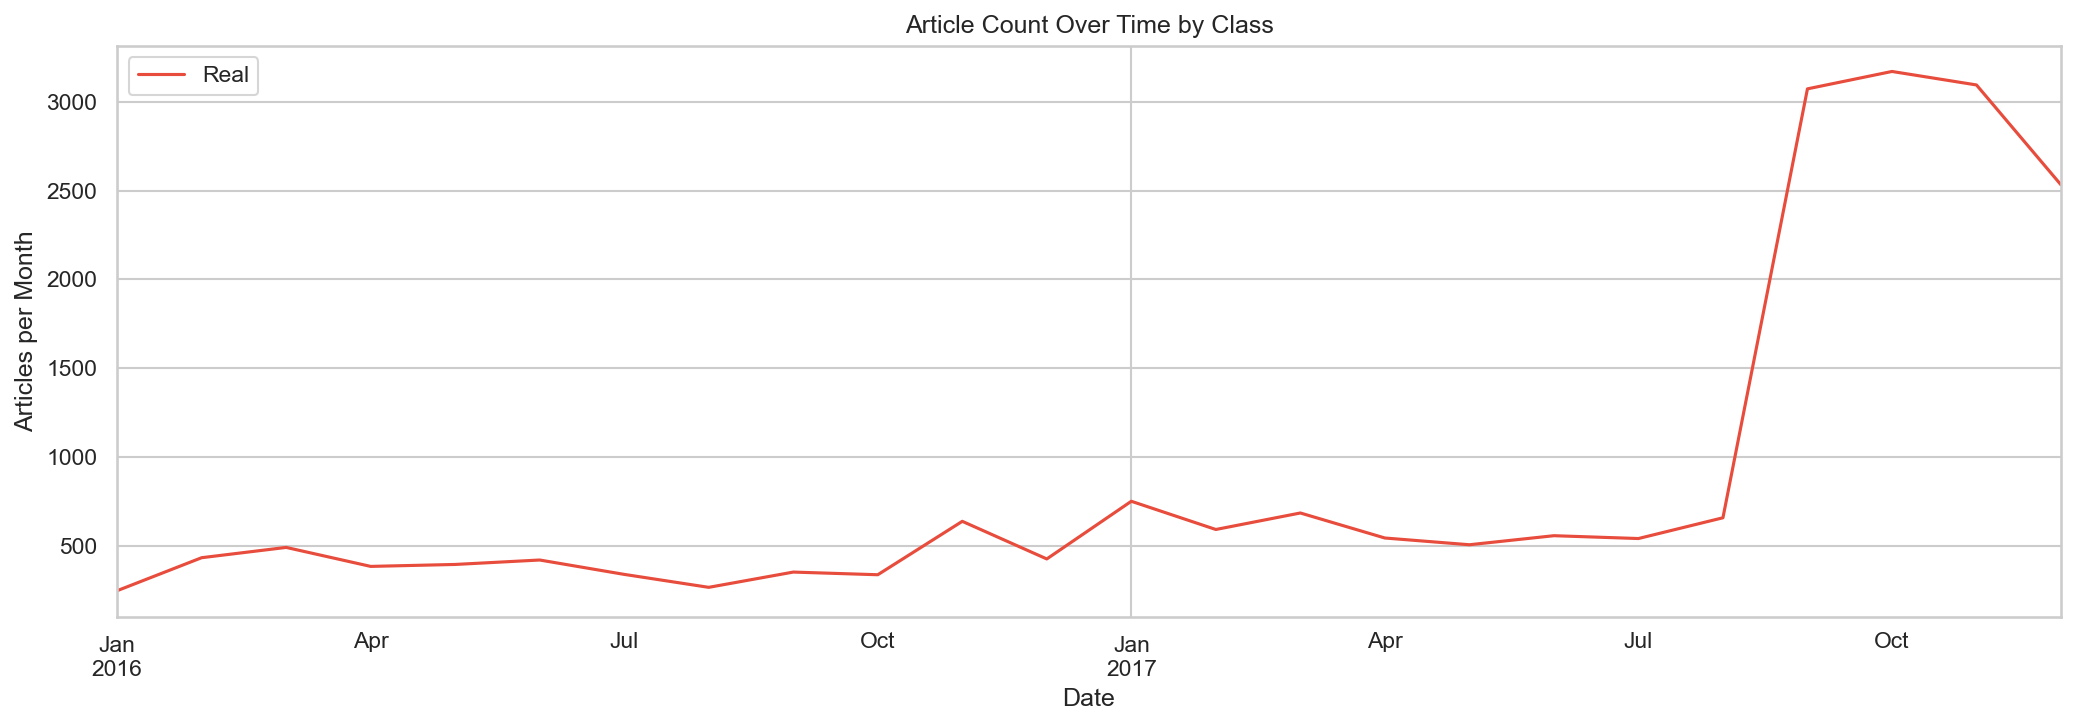

In [9]:
news_df["date_parsed"] = pd.to_datetime(news_df["date"], errors="coerce")

print(f"Unparseable dates: {news_df['date_parsed'].isna().sum()}")
print(f"Date range: {news_df['date_parsed'].min()} to {news_df['date_parsed'].max()}")

monthly = (
    news_df.dropna(subset=["date_parsed"])
    .groupby([pd.Grouper(key="date_parsed", freq="ME"), "label"])
    .size()
    .unstack(fill_value=0)
)
monthly.columns = [LABEL_NAMES[c] for c in monthly.columns]

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax, color=[LABEL_COLORS[0], LABEL_COLORS[1]])
ax.set_title("Article Count Over Time by Class")
ax.set_xlabel("Date")
ax.set_ylabel("Articles per Month")
plt.tight_layout()
plt.show()

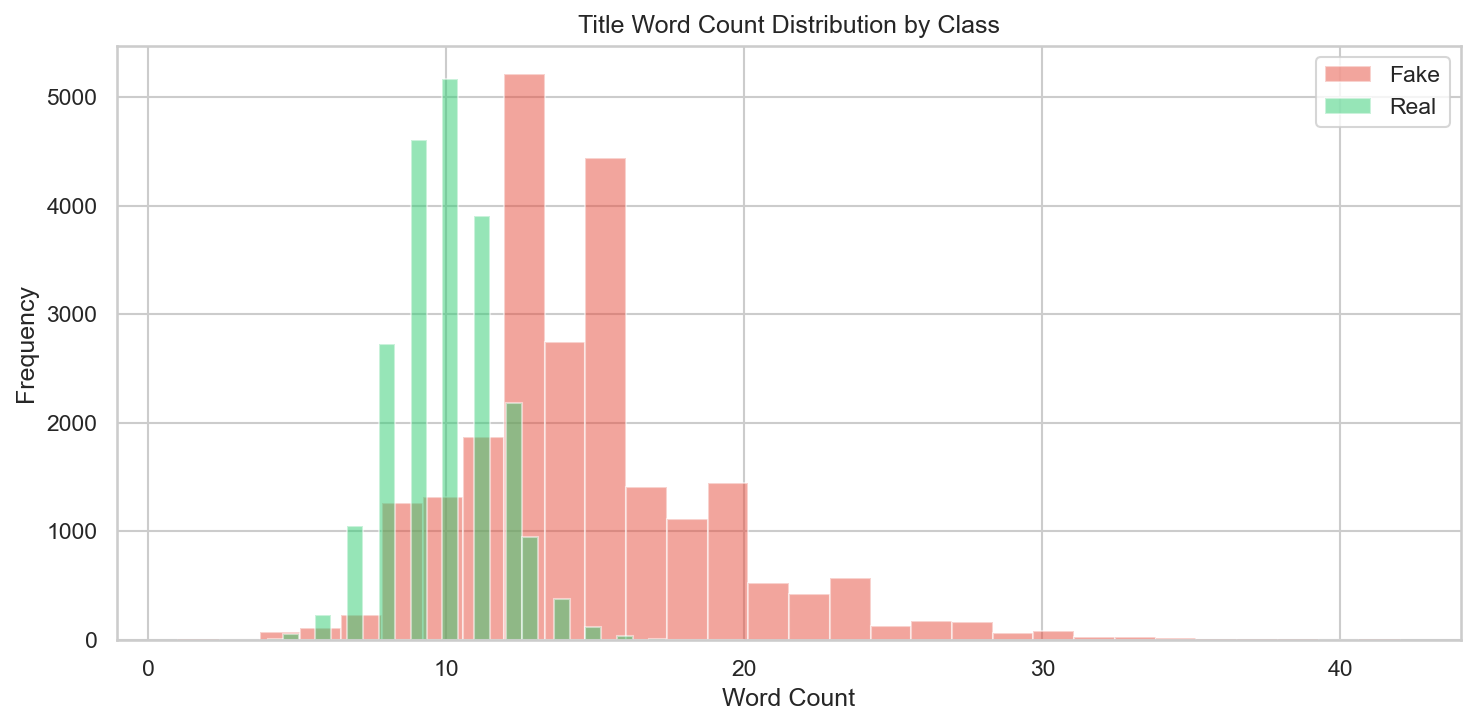

Title word count stats by class:
         count       mean       std  min   25%   50%   75%   max
label                                                           
0      23481.0  14.732805  4.335099  1.0  12.0  14.0  17.0  42.0
1      21417.0   9.954475  1.700747  4.0   9.0  10.0  11.0  20.0


In [12]:
news_df["title_word_count"] = news_df["title"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]
    ax.hist(subset["title_word_count"].dropna(), bins=30, alpha=0.5,
            label=name, color=LABEL_COLORS[label])
    
ax.set_title("Title Word Count Distribution by Class")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

print("Title word count stats by class:")
print(news_df.groupby("label")["title_word_count"].describe())

**Rationale for dropping metadata columns:**
- **subject** — categories are completely different between classes (e.g. `politicsNews` only in real), making it a trivially leaking feature
- **date** — temporal patterns may reflect collection methodology rather than content differences
- **title** — redundant with the article text; using both would complicate the model without clear benefit

From this point forward we work with `text` and `label` only.

In [13]:
news_df = news_df[["text", "label"]].copy()
news_df.head()

,text,label
0,"WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fis...",1
1,"WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after Pres...",1
2,"WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election campaign should continue without interference in 2018, despite calls from some ...",1
3,"WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russia had political dirt on Democratic presidential candidate Hillary Clinton, the N...",1
4,"SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Service on Friday to charge “much more” to ship packages for Amazon (AMZN.O), picking another fight with an online r...",1


## 3. Class Distribution

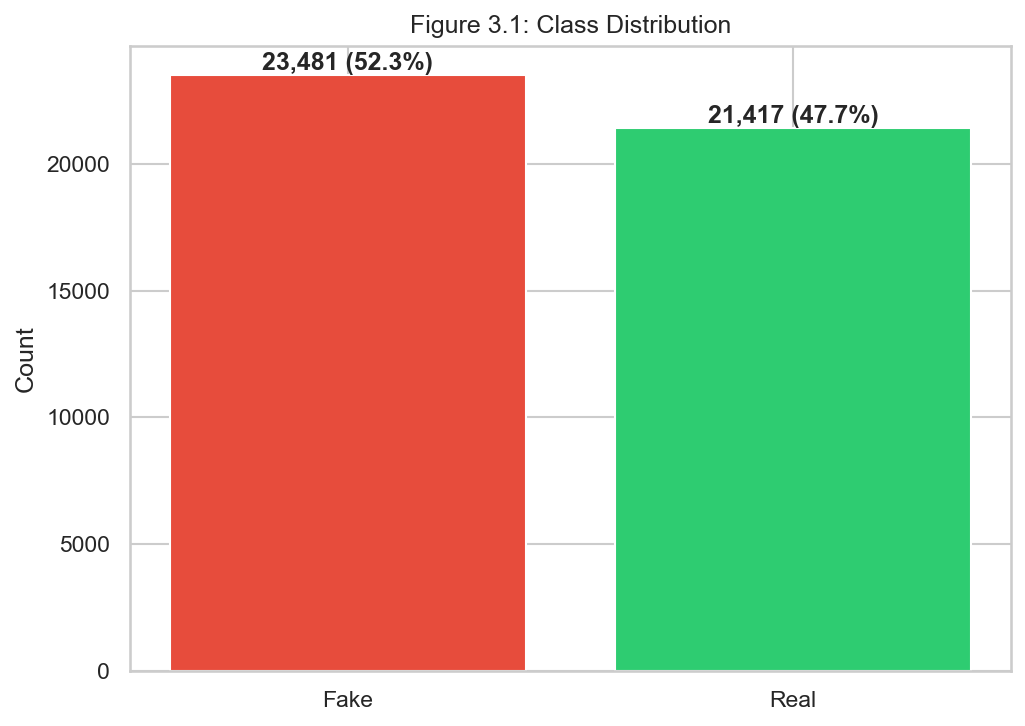

Imbalance ratio (Fake/Real): 1.096
With a ratio of 1.10:1, classes are near-balanced.
No resampling or class weighting is required for training.


In [14]:
counts = news_df["label"].value_counts().sort_index()
labels = [LABEL_NAMES[i] for i in counts.index]
colors = [LABEL_COLORS[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f"{val:,} ({pct:.1f}%)", ha="center", fontweight="bold")
    
ax.set_title("Figure 3.1: Class Distribution")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f"Imbalance ratio (Fake/Real): {ratio:.3f}")
print(f"With a ratio of {ratio:.2f}:1, classes are near-balanced.")
print("No resampling or class weighting is required for training.")

## 4. Missing and Empty Text

In [ ]:
print("Null values per column:")
print(news_df.isnull().sum())

empty_mask = news_df["text"].fillna("").str.strip() == ""
short_mask = news_df["text"].fillna("").str.strip().str.len().between(1, 9)

print(f"\nEmpty text rows: {empty_mask.sum()}")
print(f"Near-empty text rows (1-9 chars): {short_mask.sum()}")

print(f"\nEmpty texts by class:")
print(news_df[empty_mask]["label"].map(LABEL_NAMES).value_counts())

problematic = empty_mask | short_mask
if problematic.sum() > 0:
    print(f"\nExamples of empty/near-empty texts:")
    display(news_df[problematic].head(10))

Null values per column:
text     0
label    0
dtype: int64

Empty text rows: 631
Near-empty text rows (1-9 chars): 22

Empty texts by class:
label
Fake    630
Real      1
Name: count, dtype: int64

Examples of empty/near-empty texts:


,text,label
8970,,1
32340,,0
32458,,0
32534,Enjoy:,0
32607,,0
32642,,0
32653,,0
32658,,0
32664,,0
32666,,0


## 5. Duplicate Analysis

Exact duplicate rows: 5,611 (12.7%)
Duplicate texts (ignoring label): 5,611
  Fake: 5,386 duplicates
  Real: 225 duplicates


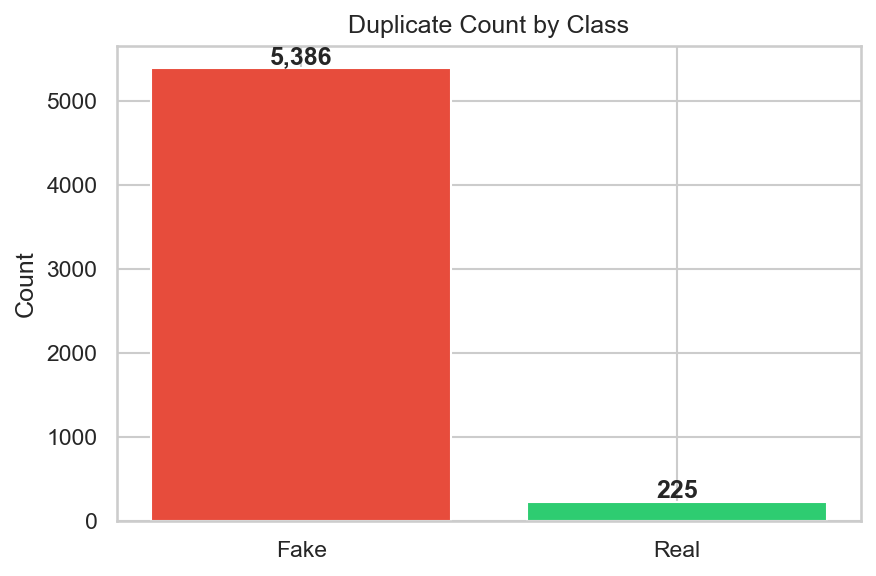

In [29]:
total_dups = news_df.duplicated().sum()
text_dups = news_df.duplicated(subset=["text"]).sum()
print(f"Exact duplicate rows: {total_dups:,} ({total_dups / len(news_df) * 100:.1f}%)")
print(f"Duplicate texts (ignoring label): {text_dups:,}")

dup_by_class = []
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]
    n = subset.duplicated(subset=["text"]).sum()
    dup_by_class.append({"Class": name, "Duplicates": n})
    print(f"  {name}: {n:,} duplicates")

fig, ax = plt.subplots(figsize=(6, 4))
dup_df = pd.DataFrame(dup_by_class)
bars = ax.bar(dup_df["Class"], dup_df["Duplicates"],
              color=[LABEL_COLORS[0], LABEL_COLORS[1]])
for bar, val in zip(bars, dup_df["Duplicates"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,}", ha="center", fontweight="bold")
ax.set_title("Duplicate Count by Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [30]:
print("Top 10 most duplicated texts:")
top_dups = news_df["text"].value_counts().head(10)
for i, (text, count) in enumerate(top_dups.items(), 1):
    preview = text[:80] + "..." if len(text) > 80 else text
    preview = repr(preview) if text.strip() == "" else preview
    print(f"  {i}. (x{count}) {preview}")

print("\n--- Cross-class duplicates (same text, different labels = label noise) ---")
cross = news_df.groupby("text")["label"].nunique()
cross_count = (cross > 1).sum()
print(f"Texts appearing with BOTH labels: {cross_count}")
if cross_count > 0:
    conflict_texts = cross[cross > 1].index[:5]
    for t in conflict_texts:
        print(f"  '{t[:80]}...' — labels: {news_df[news_df['text'] == t]['label'].tolist()}")

Top 10 most duplicated texts:
  1. (x8) (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thurs...
  2. (x5) (Reuters) - Highlights for U.S. President Donald Trump’s administration on Frida...
  3. (x5) (Reuters) - Highlights of the day for U.S. President Donald Trump’s administrati...
  4. (x4) On September 15, Hillary  apparently  held a rally in the Old Student Recreation...
  5. (x4) AP News  The regulars amble in before dawn and claim their usual table, the one ...
  6. (x4) Things didn t go as well as Nicholle had hoped and now, she s lashing out at the...
  7. (x4) Because there wouldn t be any outrage over a  white kids only  field trip to a l...
  8. (x3) Every American should be demanding answers about why Barack Hussein Obama is in ...
  9. (x3) The politically correct country of Sweden paying a very big price for their kind...
  10. (x3) The cover-ups and mistruths appear to be numerous. The question Americans need t...

--- Cross-class duplicates (

## 6. Text Length Analysis

In [31]:
news_df["char_count"] = news_df["text"].str.len()
news_df["word_count"] = news_df["text"].str.split().str.len()
news_df["sentence_count"] = news_df["text"].str.count(r"[.!?]+")

print("Length statistics by class:\n")
for col in ["char_count", "word_count", "sentence_count"]:
    print(f"--- {col} ---")
    print(news_df.groupby("label")[col].describe().rename(index=LABEL_NAMES))
    print()

Length statistics by class:

--- char_count ---
         count         mean          std    min     25%     50%     75%  \
label                                                                     
Fake   22829.0  2620.115993  2531.458867   10.0  1520.0  2201.0  3059.0   
Real   21416.0  2383.389755  1684.796417  152.0   914.0  2222.0  3237.0   

           max  
label           
Fake   51794.0  
Real   29781.0  

--- word_count ---
         count        mean         std   min     25%    50%    75%     max
label                                                                     
Fake   22829.0  435.283192  407.780336   1.0  255.00  370.0  511.0  8135.0
Real   21416.0  385.658106  273.999928  22.0  148.75  359.0  525.0  5172.0

--- sentence_count ---
         count       mean        std  min   25%   50%   75%    max
label                                                             
Fake   22829.0  23.351395  21.549220  0.0  13.0  19.0  28.0  772.0
Real   21416.0  20.802204  15.912007  

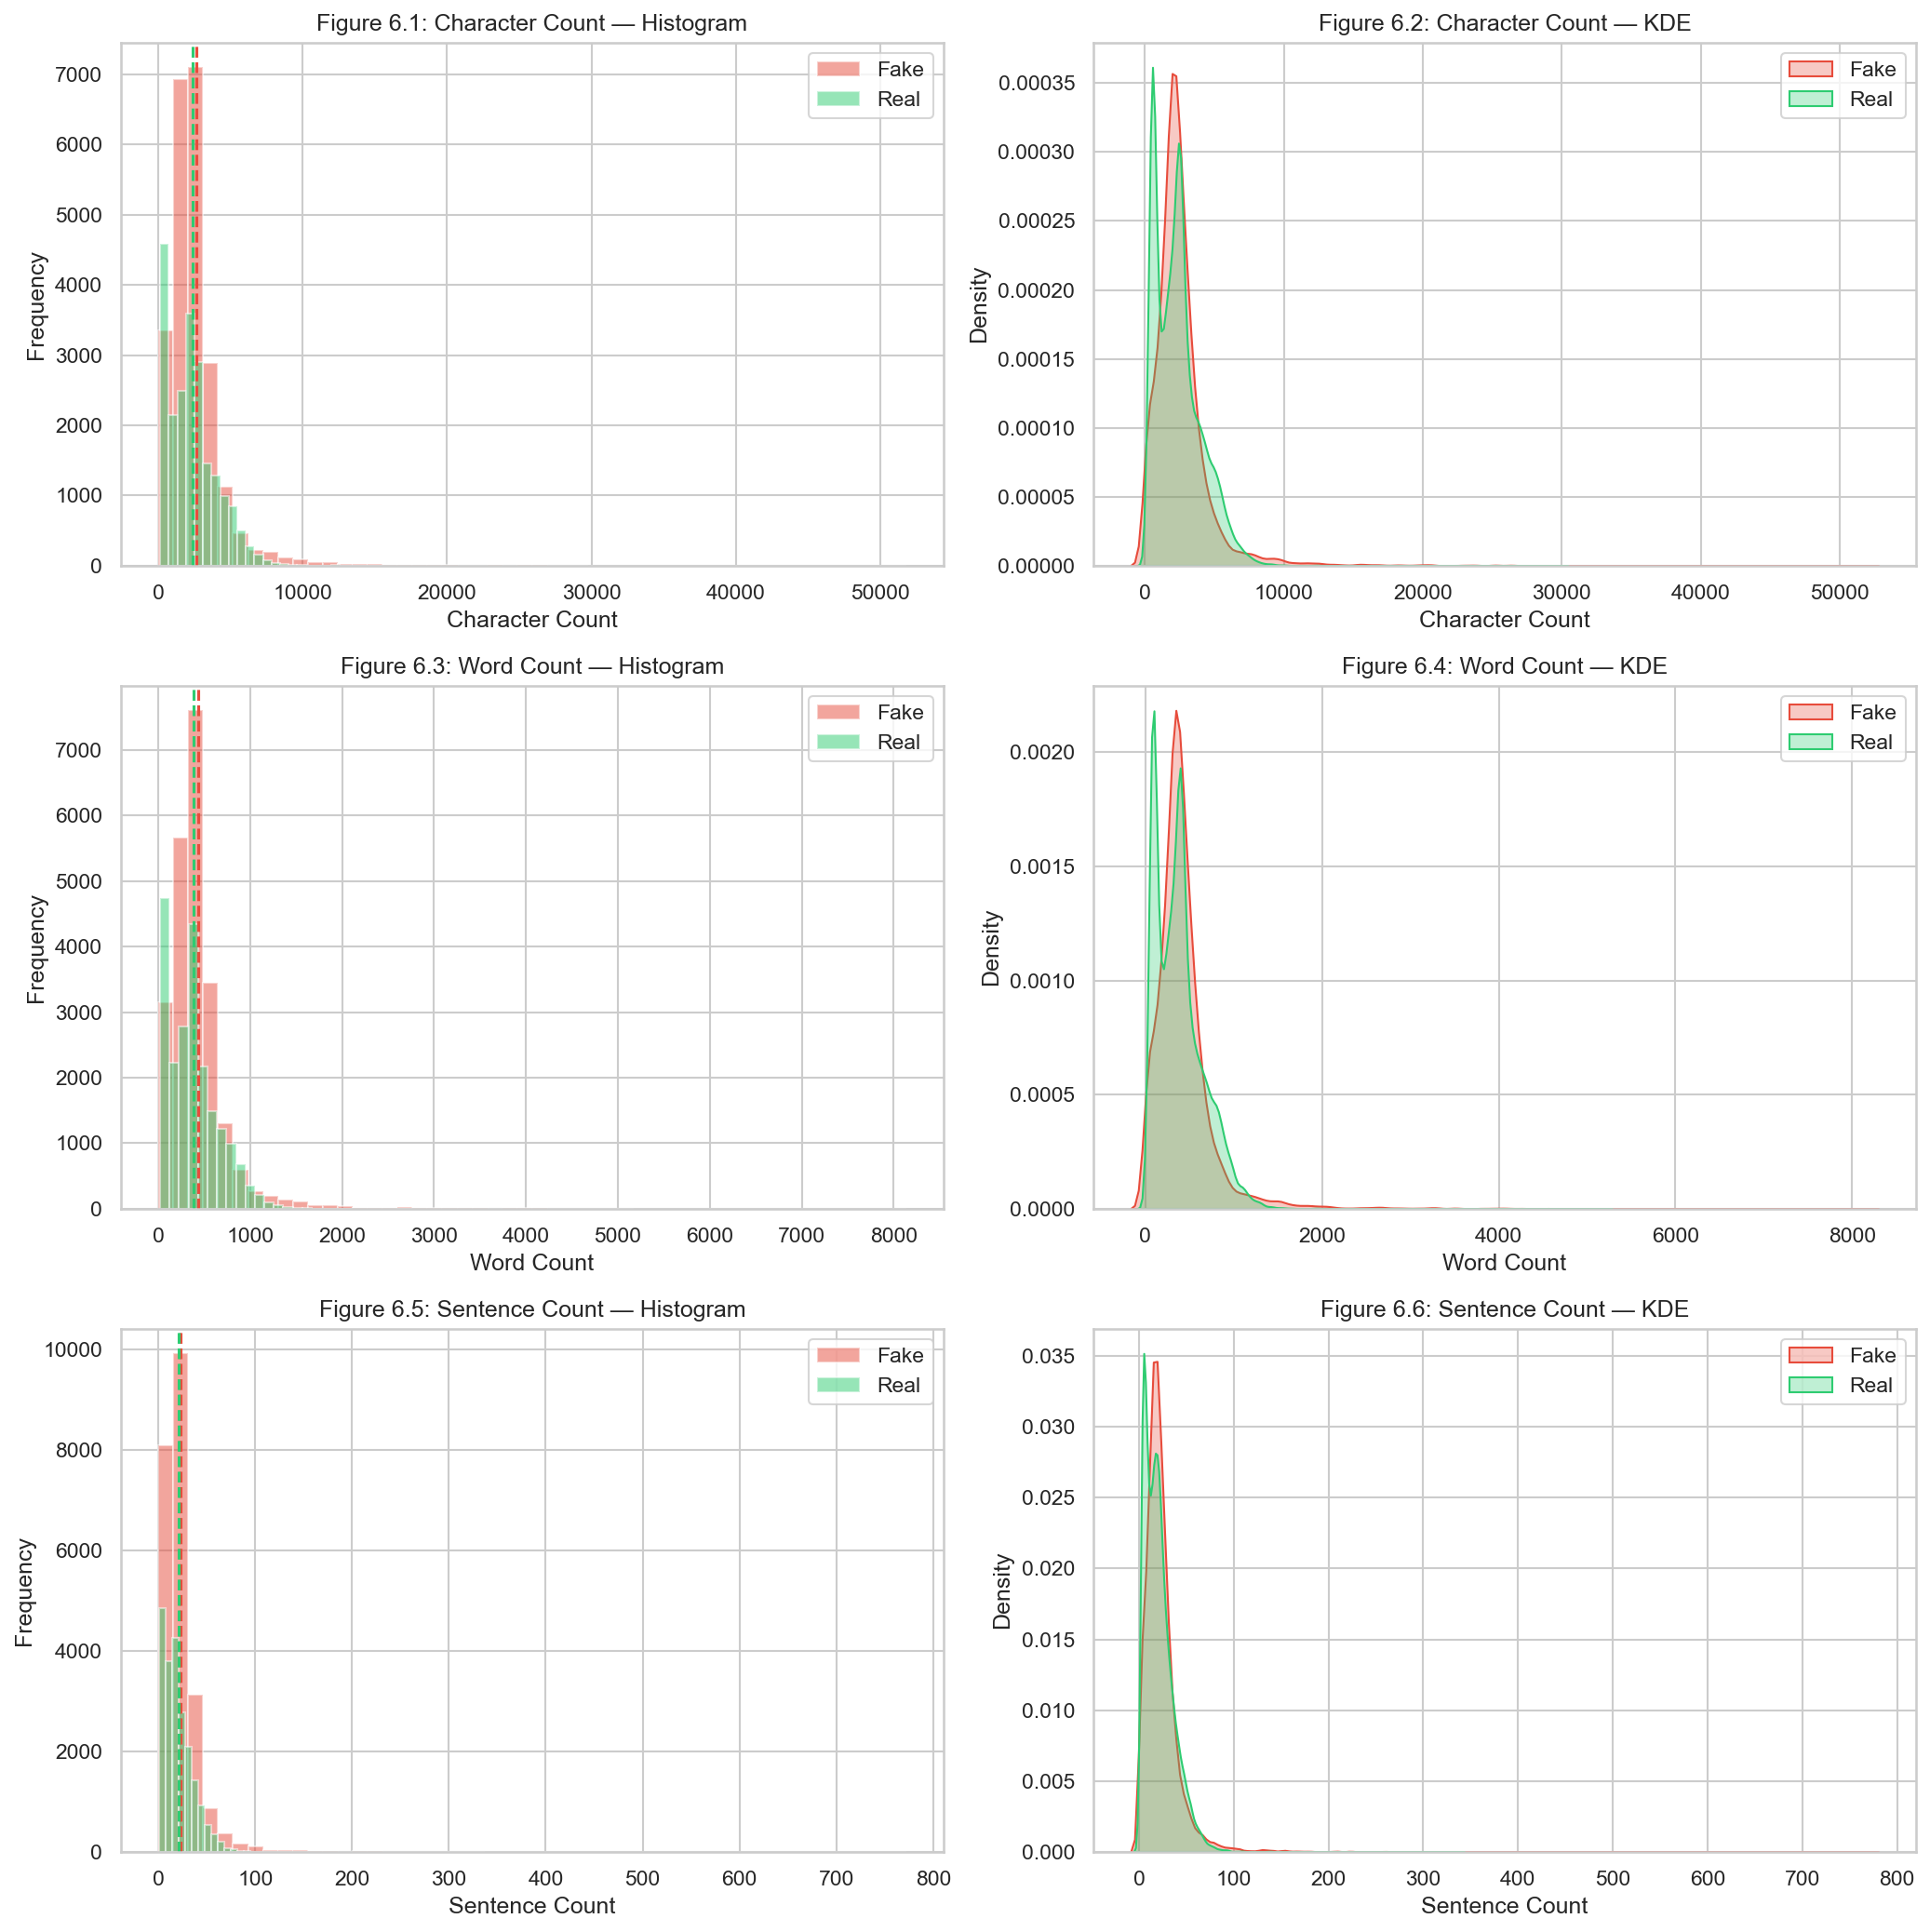

In [33]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for row, (col, title) in enumerate(zip(
    ["char_count", "word_count", "sentence_count"],
    ["Character Count", "Word Count", "Sentence Count"]
)):
    # Left: histogram
    ax_hist = axes[row, 0]
    for label, name in LABEL_NAMES.items():
        subset = news_df[news_df["label"] == label][col].dropna()
        ax_hist.hist(subset, bins=50, alpha=0.5, label=name, color=LABEL_COLORS[label])
        ax_hist.axvline(subset.mean(), color=LABEL_COLORS[label], linestyle="--", linewidth=1.5)
        
    ax_hist.set_title(f"Figure 6.{row*2+1}: {title} — Histogram")
    ax_hist.set_xlabel(title)
    ax_hist.set_ylabel("Frequency")
    ax_hist.legend()

    # Right: KDE
    ax_kde = axes[row, 1]
    for label, name in LABEL_NAMES.items():
        subset = news_df[news_df["label"] == label][col].dropna()
        sns.kdeplot(subset, ax=ax_kde, label=name, color=LABEL_COLORS[label],
                    fill=True, alpha=0.3, common_norm=False)
        
    ax_kde.set_title(f"Figure 6.{row*2+2}: {title} — KDE")

    ax_kde.set_xlabel(title)
    ax_kde.legend()

plt.tight_layout()
plt.show()

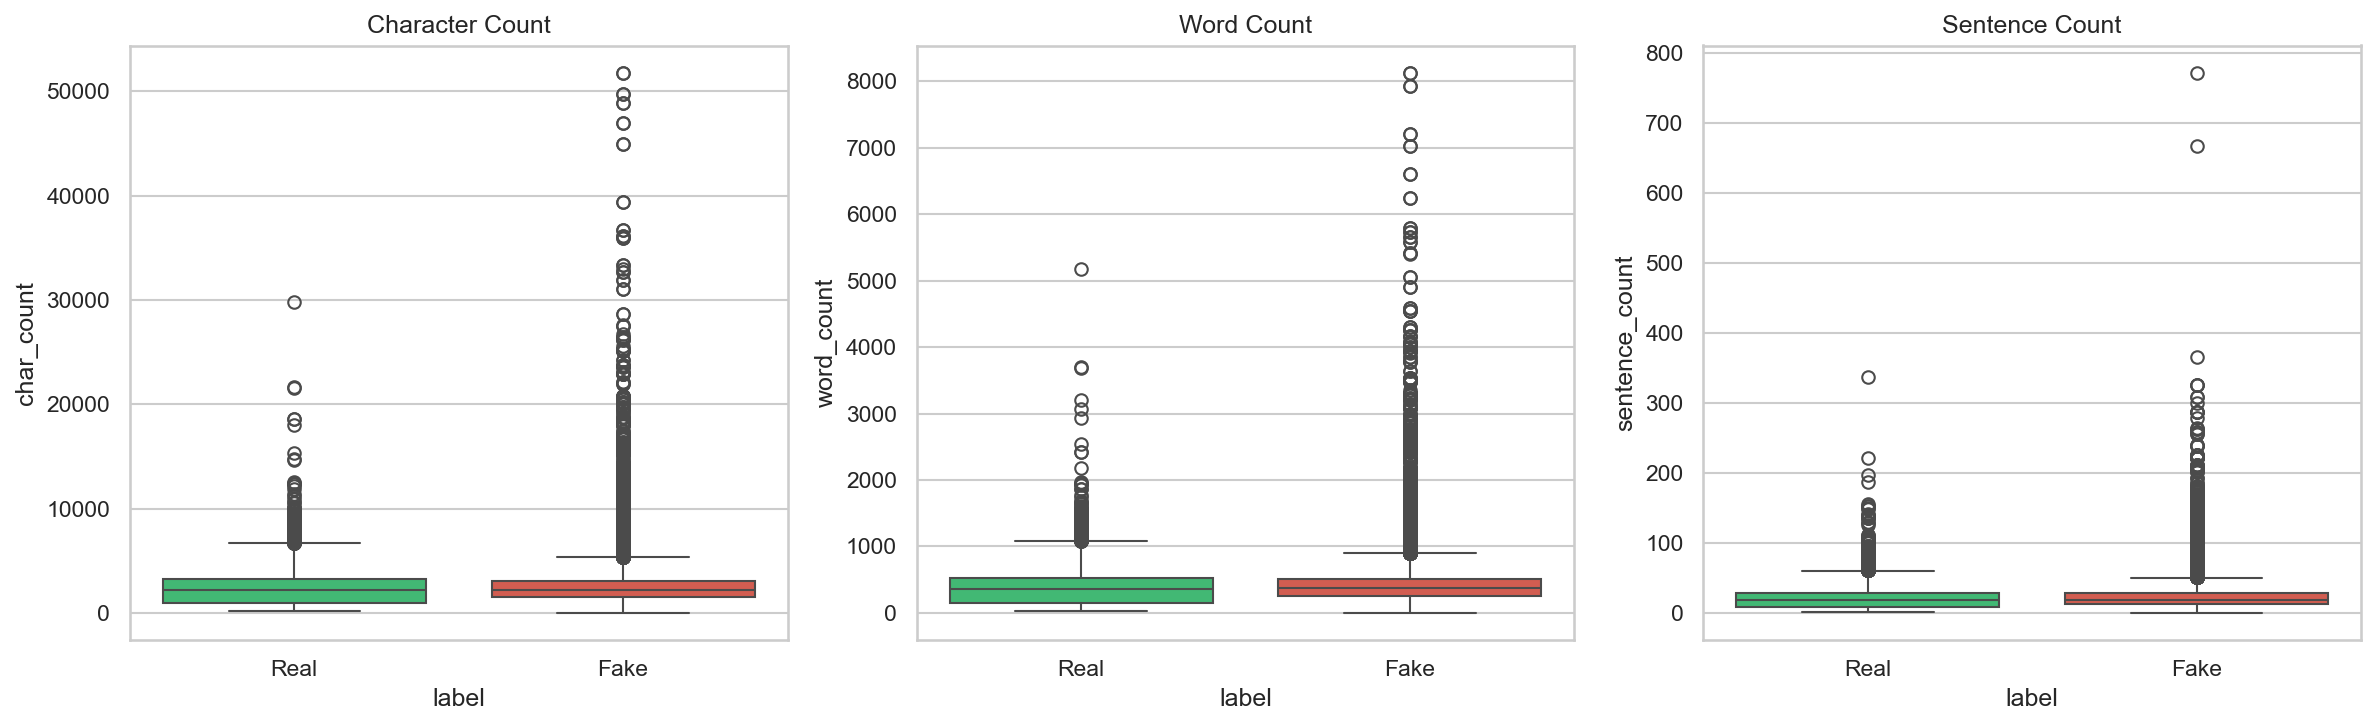

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes, ["char_count", "word_count", "sentence_count"],
                           ["Character Count", "Word Count", "Sentence Count"]):
    plot_df = news_df[["label", col]].copy()
    plot_df["label"] = plot_df["label"].map(LABEL_NAMES)
    sns.boxplot(data=plot_df, x="label", y=col, ax=ax,
                palette={"Fake": LABEL_COLORS[0], "Real": LABEL_COLORS[1]}, hue="label", legend=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [ ]:
real_wc = news_df[news_df["label"] == 1]["word_count"].dropna()
fake_wc = news_df[news_df["label"] == 0]["word_count"].dropna()

stat, p_value = mannwhitneyu(real_wc, fake_wc, alternative="two-sided")
n1, n2 = len(real_wc), len(fake_wc)
r = 1 - (2 * stat) / (n1 * n2)

print("Mann-Whitney U test (word count: Real vs Fake):")
print(f"  U_real statistic: {stat:,.0f}")
print(f"  p-value: {p_value:.2e}")
print(f"  Rank-biserial correlation r = {r:.4f}")

# Interpret effect size magnitude
abs_r = abs(r)
if abs_r < 0.1:
    magnitude = "negligible"
elif abs_r < 0.3:
    magnitude = "small"
elif abs_r < 0.5:
    magnitude = "medium"
else:
    magnitude = "large"

direction = "higher" if r > 0 else "lower"
print(f"\n  Interpretation: Real articles tend to have {direction} word counts than fake articles.")
print(f"  Effect size: |r| = {abs_r:.4f} — {magnitude} practical effect.")
print(f"\n  Note: With N = {n1 + n2:,}, the p-value is not informative on its own;")
print(f"  virtually any difference is statistically significant at this sample size.")
print(f"  The rank-biserial correlation ({magnitude} effect) is the meaningful metric here.")

print(f"\n--- Outliers ---")
very_short = news_df[news_df["word_count"] < 5]
very_long = news_df[news_df["word_count"] > 5000]
print(f"Articles with < 5 words: {len(very_short)}")
print(f"Articles with > 5000 words: {len(very_long)}")

print(f"\nShortest articles:")
display(very_short.nsmallest(15, "word_count")[["text", "label", "word_count"]])
print(f"\nLargest articles:")
display(very_long.nlargest(n=15, columns="word_count")[["text", "label", "word_count"]])

Mann-Whitney U test (word count: Real vs Fake):
  U_real statistic: 227,494,074
  p-value: 1.42e-36
  Rank-biserial correlation r = 0.0694

  Interpretation: Real articles tend to have higher word counts than fake articles.
  Effect size: |r| = 0.0694 — negligible practical effect.

  Note: With N = 44,245, the p-value is not informative on its own;
  virtually any difference is statistically significant at this sample size.
  The rank-biserial correlation (negligible effect) is the meaningful metric here.

--- Outliers ---
Articles with < 5 words: 121
Articles with > 5000 words: 26

Shortest articles:


,text,label,word_count
30774,https://100percentfedup.com/served-roy-moore-vietnamletter-veteran-sets-record-straight-honorable-decent-respectable-patriotic-commander-soldier/,0,1
32658,https://www.youtube.com/watch?v=cJZFepSvxzM,0,1
32688,https://www.youtube.com/watch?v=-7Tn4gi_Os8,0,1
32690,https://www.youtube.com/watch?time_continue=2&v=IjWClQcKhD8,0,1
32706,https://www.youtube.com/watch?v=SH0pRtK9sAE,0,1
32707,https://www.youtube.com/watch?v=DRLVvYzG46w,0,1
32716,https://www.youtube.com/watch?v=Ws5ojb0PCCo,0,1
32762,https://www.youtube.com/watch?v=P-TBfkqk7gU,0,1
32796,https://www.youtube.com/watch?v=yRXmFmgoPTk,0,1
32842,https://www.youtube.com/watch?v=n9tfNMQpYWU,0,1


,text,label,word_count
43067,"Funny how secrets travel. I d start to believe, if I were to bleed. Lyrics written by David Bowie from the album OutsideShawn Helton 21st Century Wire In the days before the US presidential el...",0,8135
43850,"Funny how secrets travel. I d start to believe, if I were to bleed. Lyrics written by David Bowie from the album OutsideShawn Helton 21st Century Wire In the days before the US presidential el...",0,8135
42742,Shawn Helton 21st Century WireAlthough many are still stunned in the aftermath of the Route 91 Festival tragedy a series of unanswered questions persist following what has been described by med...,0,7928
43525,Shawn Helton 21st Century WireAlthough many are still stunned in the aftermath of the Route 91 Festival tragedy a series of unanswered questions persist following what has been described by med...,0,7928
43270,"Shawn Helton 21st Century WireThe 1994 cult film Natural Born Killers, is an examination of media manipulation, archetypal psychology and the violence embedded within American pop culture.Although...",0,7209
44053,"Shawn Helton 21st Century WireThe 1994 cult film Natural Born Killers, is an examination of media manipulation, archetypal psychology and the violence embedded within American pop culture.Although...",0,7209
31147,We just discovered another reason NOT to support the NFL The man who is the most anti-American person we know is now connected to The National Football League Players Association (NFLPA) The NFLP...,0,7033
38770,We just discovered another reason NOT to support the NFL The man who is the most anti-American person we know is now connected to The National Football League Players Association (NFLPA) The NFLP...,0,7033
33562,"There have been many articles written about George Soros and his collectivist activism. Soros is a business magnate, investor, philanthropist, and author who is of Jewish-Hungarian ancestry and ho...",0,6608
40440,"There have been many articles written about George Soros and his collectivist activism. Soros is a business magnate, investor, philanthropist, and author who is of Jewish-Hungarian ancestry and ho...",0,6608


Average sentence length (words per sentence) by class:

         count   mean   std   min    25%    50%    75%    max
label                                                        
Fake   22616.0  19.54  6.37  0.33  15.80  19.00  22.60  128.0
Real   21416.0  19.94  6.01  4.40  15.86  19.33  23.19   81.0


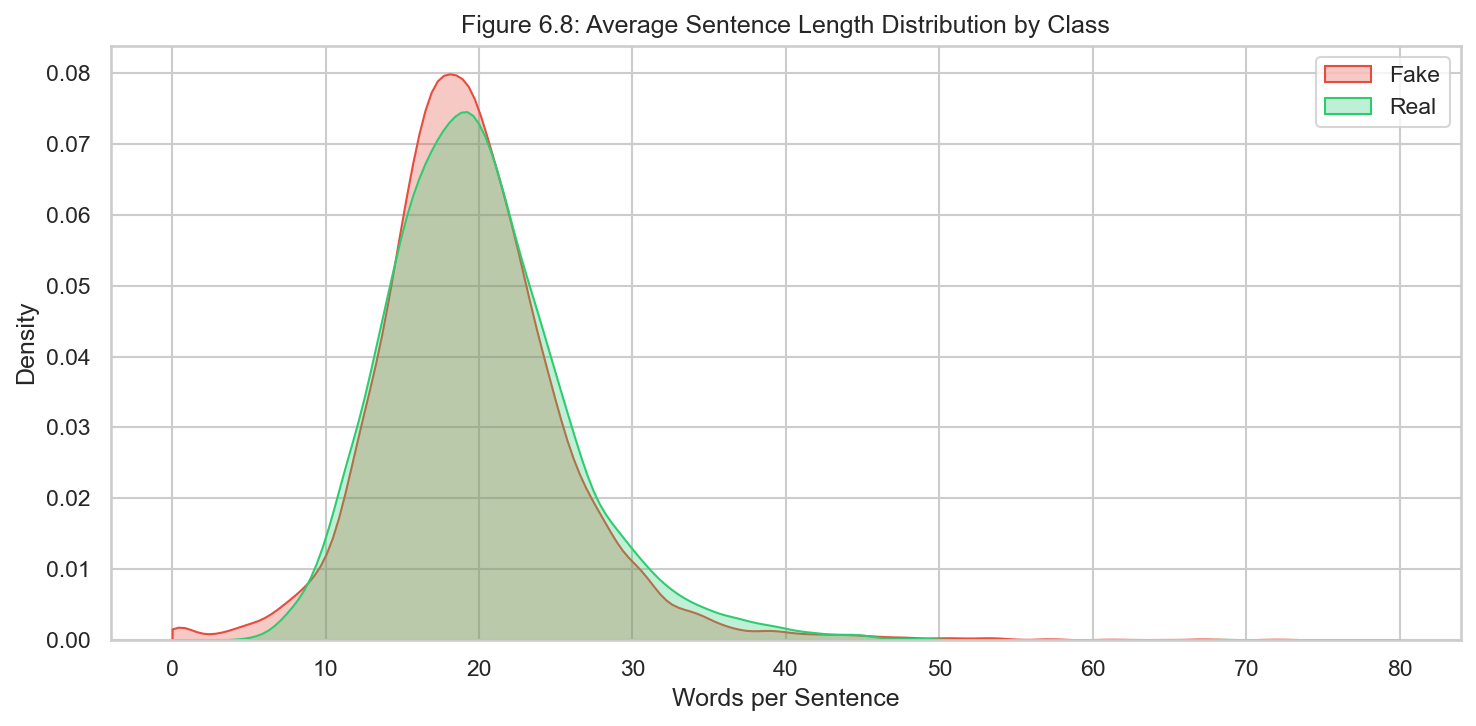

In [39]:
news_df["avg_sentence_len"] = news_df["word_count"] / news_df["sentence_count"].replace(0, np.nan)

print("Average sentence length (words per sentence) by class:\n")
print(news_df.groupby("label")["avg_sentence_len"].describe().rename(index=LABEL_NAMES).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]["avg_sentence_len"].dropna()
    sns.kdeplot(subset, ax=ax, label=name, color=LABEL_COLORS[label],
                fill=True, alpha=0.3, common_norm=False, clip=(0, 80))
    
ax.set_title("Figure 6.8: Average Sentence Length Distribution by Class")
ax.set_xlabel("Words per Sentence")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Content Patterns — Reuters & Structural Signatures

The real articles originate from Reuters. Do structural markers create data leakage?

Articles containing '(Reuters)': 21,256 / 44,898

Breakdown by class:
label
Real    21247
Fake        9
Name: count, dtype: int64


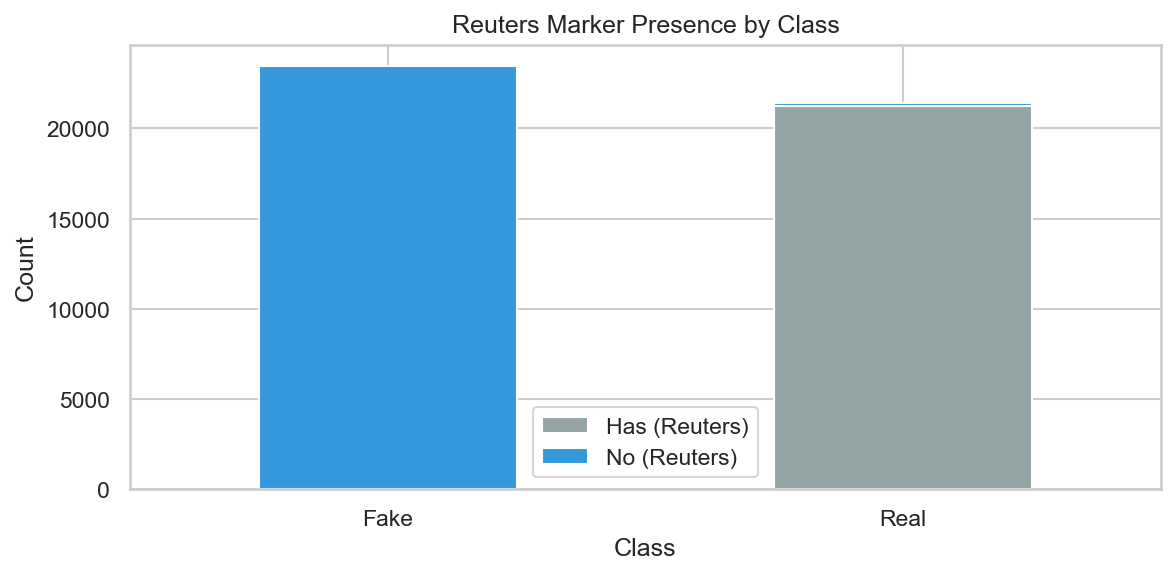


99.2% of real articles contain '(Reuters)' — this is a near-perfect class separator!
>> CRITICAL: Must remove '(Reuters)' to prevent trivial data leakage.


In [48]:
reuters_mask = news_df["text"].str.contains(r"\(Reuters\)", na=False)

print(f"Articles containing '(Reuters)': {reuters_mask.sum():,} / {len(news_df):,}")
print(f"\nBreakdown by class:")
reuters_by_class = news_df[reuters_mask]["label"].value_counts().rename(index=LABEL_NAMES)
print(reuters_by_class)

fig, ax = plt.subplots(figsize=(8, 4))
cross_tab = pd.crosstab(
    news_df["label"].map(LABEL_NAMES),
    reuters_mask.map({True: "Has (Reuters)", False: "No (Reuters)"})
)
cross_tab.plot(kind="bar", stacked=True, ax=ax,
               color=["#95a5a6", "#3498db"])
ax.set_title("Reuters Marker Presence by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pct = reuters_by_class.get("Real", 0) / counts[1] * 100
print(f"\n{pct:.1f}% of real articles contain '(Reuters)' — this is a near-perfect class separator!")
print(">> CRITICAL: Must remove '(Reuters)' to prevent trivial data leakage.")

Articles with CITY (Reuters) dateline: 17,808

Top 15 dateline cities:
text
WASHINGTON        6392
LONDON             705
NEW YORK           696
MOSCOW             623
BERLIN             500
BEIJING            433
BRUSSELS           346
BEIRUT             346
PARIS              301
ANKARA             247
MEXICO CITY        226
TOKYO              207
SEOUL              203
GENEVA             197
UNITED NATIONS     184
Name: count, dtype: int64


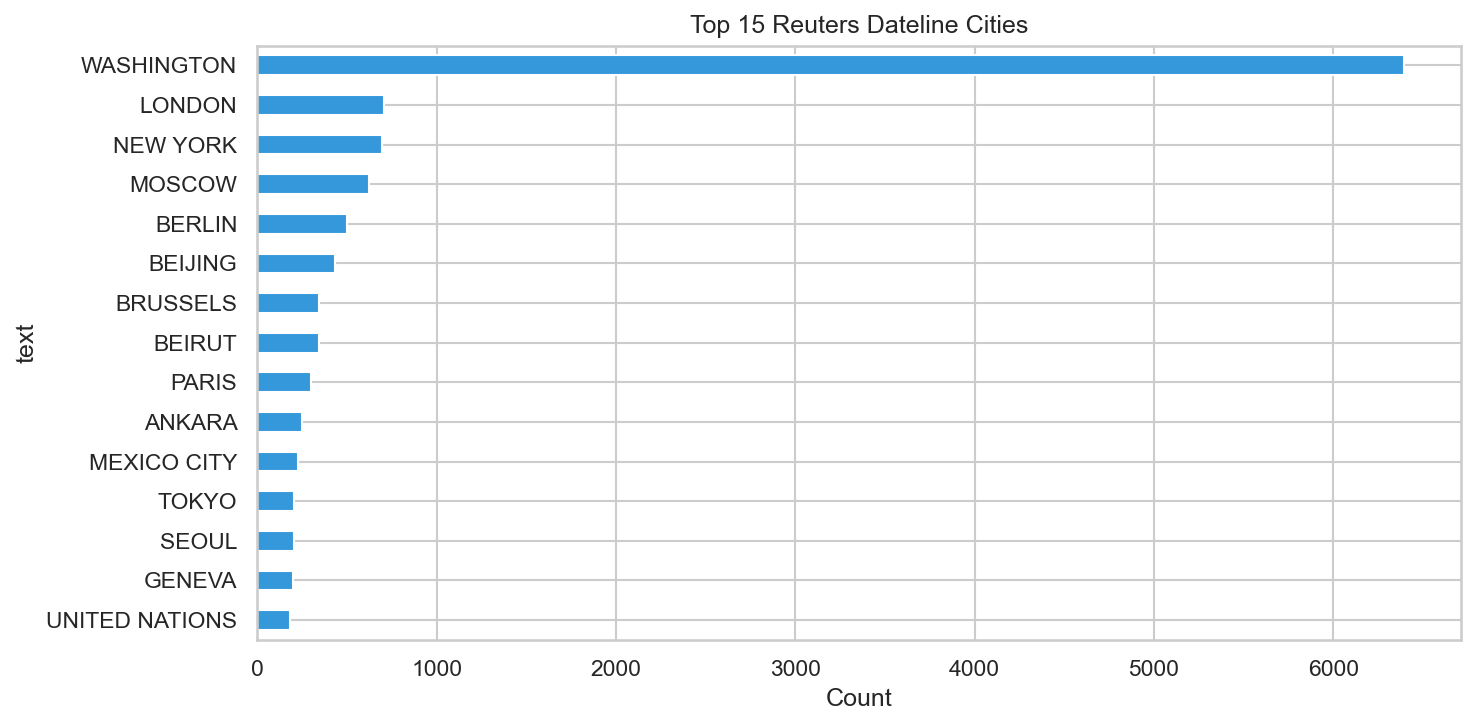

In [49]:
city_pattern = r"^([A-Z][A-Z /]+)\(Reuters\)"
cities = news_df["text"].str.extract(city_pattern, expand=False).dropna().str.strip()

print(f"Articles with CITY (Reuters) dateline: {len(cities):,}")
print(f"\nTop 15 dateline cities:")
top_cities = cities.value_counts().head(15)
print(top_cities)

fig, ax = plt.subplots(figsize=(10, 5))
top_cities.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 15 Reuters Dateline Cities")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
# After removing (Reuters), city dateline prefixes like "WASHINGTON - " will remain.
# These are also class-correlated leakage signals.
dateline_pattern = r"^[A-Z][A-Z /]+ - "
dateline_mask = news_df["text"].str.contains(dateline_pattern, na=False)

print(f"Articles with ALL-CAPS dateline prefix (e.g. 'WASHINGTON - '): {dateline_mask.sum():,}")
print(f"\nBreakdown by class:")
dateline_by_class = news_df[dateline_mask]["label"].value_counts().rename(index=LABEL_NAMES)
print(dateline_by_class)

if dateline_by_class.get("Real", 0) > 0:
    pct_real = dateline_by_class["Real"] / counts[1] * 100
    pct_fake = dateline_by_class.get("Fake", 0) / counts[0] * 100
    print(f"\n  {pct_real:.1f}% of real articles vs {pct_fake:.1f}% of fake articles have this pattern.")
    print(f"  >> This is a residual leakage signal that persists after '(Reuters)' removal.")
    print(f"  >> RECOMMENDATION: Strip the dateline prefix to prevent leakage.")

Articles with ALL-CAPS dateline prefix (e.g. 'WASHINGTON - '): 27

Breakdown by class:
label
Real    27
Name: count, dtype: int64

  0.1% of real articles vs 0.0% of fake articles have this pattern.
  >> This is a residual leakage signal that persists after '(Reuters)' removal.
  >> RECOMMENDATION: Strip the dateline prefix to prevent leakage.


In [51]:
print("Common text prefixes (first 50 chars) per class:\n")
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]["text"]
    prefixes = subset.str[:50].value_counts().head(10)
    print(f"--- {name} News ---")
    for prefix, cnt in prefixes.items():
        print(f"  (x{cnt}) {prefix}")
    print()

Common text prefixes (first 50 chars) per class:

--- Fake News ---
  (x626)  
  (x203) Tune in to the Alternate Current Radio Network (AC
  (x12) 21st Century Wire says Our weekly documentary film
  (x12) Join Patrick every Wednesday at Independent Talk 1
  (x10)  In response to the establishment media s contrive
  (x8)  Join Patrick every Wednesday at Independent Talk 
  (x6) // <![CDATA[ (function(d, s, id) { var js, fjs = d
  (x6) https://fedup.wpengine.com/wp-content/uploads/2015
  (x5) Obama has filled his cabinet with radical  yes  me
  (x4) In fly-over country, and pretty much anywhere in b

--- Real News ---
  (x540) WASHINGTON (Reuters) - U.S. President Donald Trump
  (x91) The following statements were posted to the verifi
  (x87) WASHINGTON (Reuters) - U.S. President Barack Obama
  (x76) WASHINGTON (Reuters) - The U.S. House of Represent
  (x76) WASHINGTON (Reuters) - U.S. Secretary of State Rex
  (x75) WASHINGTON (Reuters) - President-elect Donald Trum
  (x74) WASHINGTON (

In [52]:
# Note: ALL-CAPS count is confounded by Reuters dateline cities.
# We compute it both raw and after excluding dateline-only patterns.
url_mask = news_df["text"].str.contains(r"https?://", na=False)

# Strip dateline prefix before counting ALL-CAPS to avoid confound
text_no_dateline = news_df["text"].str.replace(r"^[A-Z][A-Z /]+(\(Reuters\))?\s*-?\s*", "", regex=True)
allcaps_count = text_no_dateline.str.count(r"\b[A-Z]{3,}\b")

patterns = pd.DataFrame({
    "label": news_df["label"].map(LABEL_NAMES),
    "has_url": url_mask,
    "allcaps_words": allcaps_count,
    "exclamation_marks": news_df["text"].str.count("!"),
    "question_marks": news_df["text"].str.count(r"\?"),
})

print("Structural patterns by class (ALL-CAPS computed after stripping dateline prefix):\n")
print(patterns.groupby("label").agg({
    "has_url": "sum",
    "allcaps_words": "mean",
    "exclamation_marks": "mean",
    "question_marks": "mean",
}).round(2).rename(columns={
    "has_url": "Articles with URLs",
    "allcaps_words": "Avg ALL-CAPS words",
    "exclamation_marks": "Avg ! marks",
    "question_marks": "Avg ? marks",
}))

Structural patterns by class (ALL-CAPS computed after stripping dateline prefix):

       Articles with URLs  Avg ALL-CAPS words  Avg ! marks  Avg ? marks
label                                                                  
Fake                 3299                4.78         0.72         1.21
Real                    0                2.00         0.06         0.10


## 8. Word Frequency Analysis

In [53]:
stop_words = set(stopwords.words("english"))

def get_word_freq(texts, remove_stopwords=True):
    words = []
    for text in texts.dropna():
        tokens = text.lower().split()
        if remove_stopwords:
            tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
        words.extend(tokens)
    return Counter(words)

real_freq = get_word_freq(news_df[news_df["label"] == 1]["text"])
fake_freq = get_word_freq(news_df[news_df["label"] == 0]["text"])

print(f"Total tokens (excl. stopwords) — Real: {sum(real_freq.values()):,}, Fake: {sum(fake_freq.values()):,}")

Total tokens (excl. stopwords) — Real: 3,913,444, Fake: 4,385,585


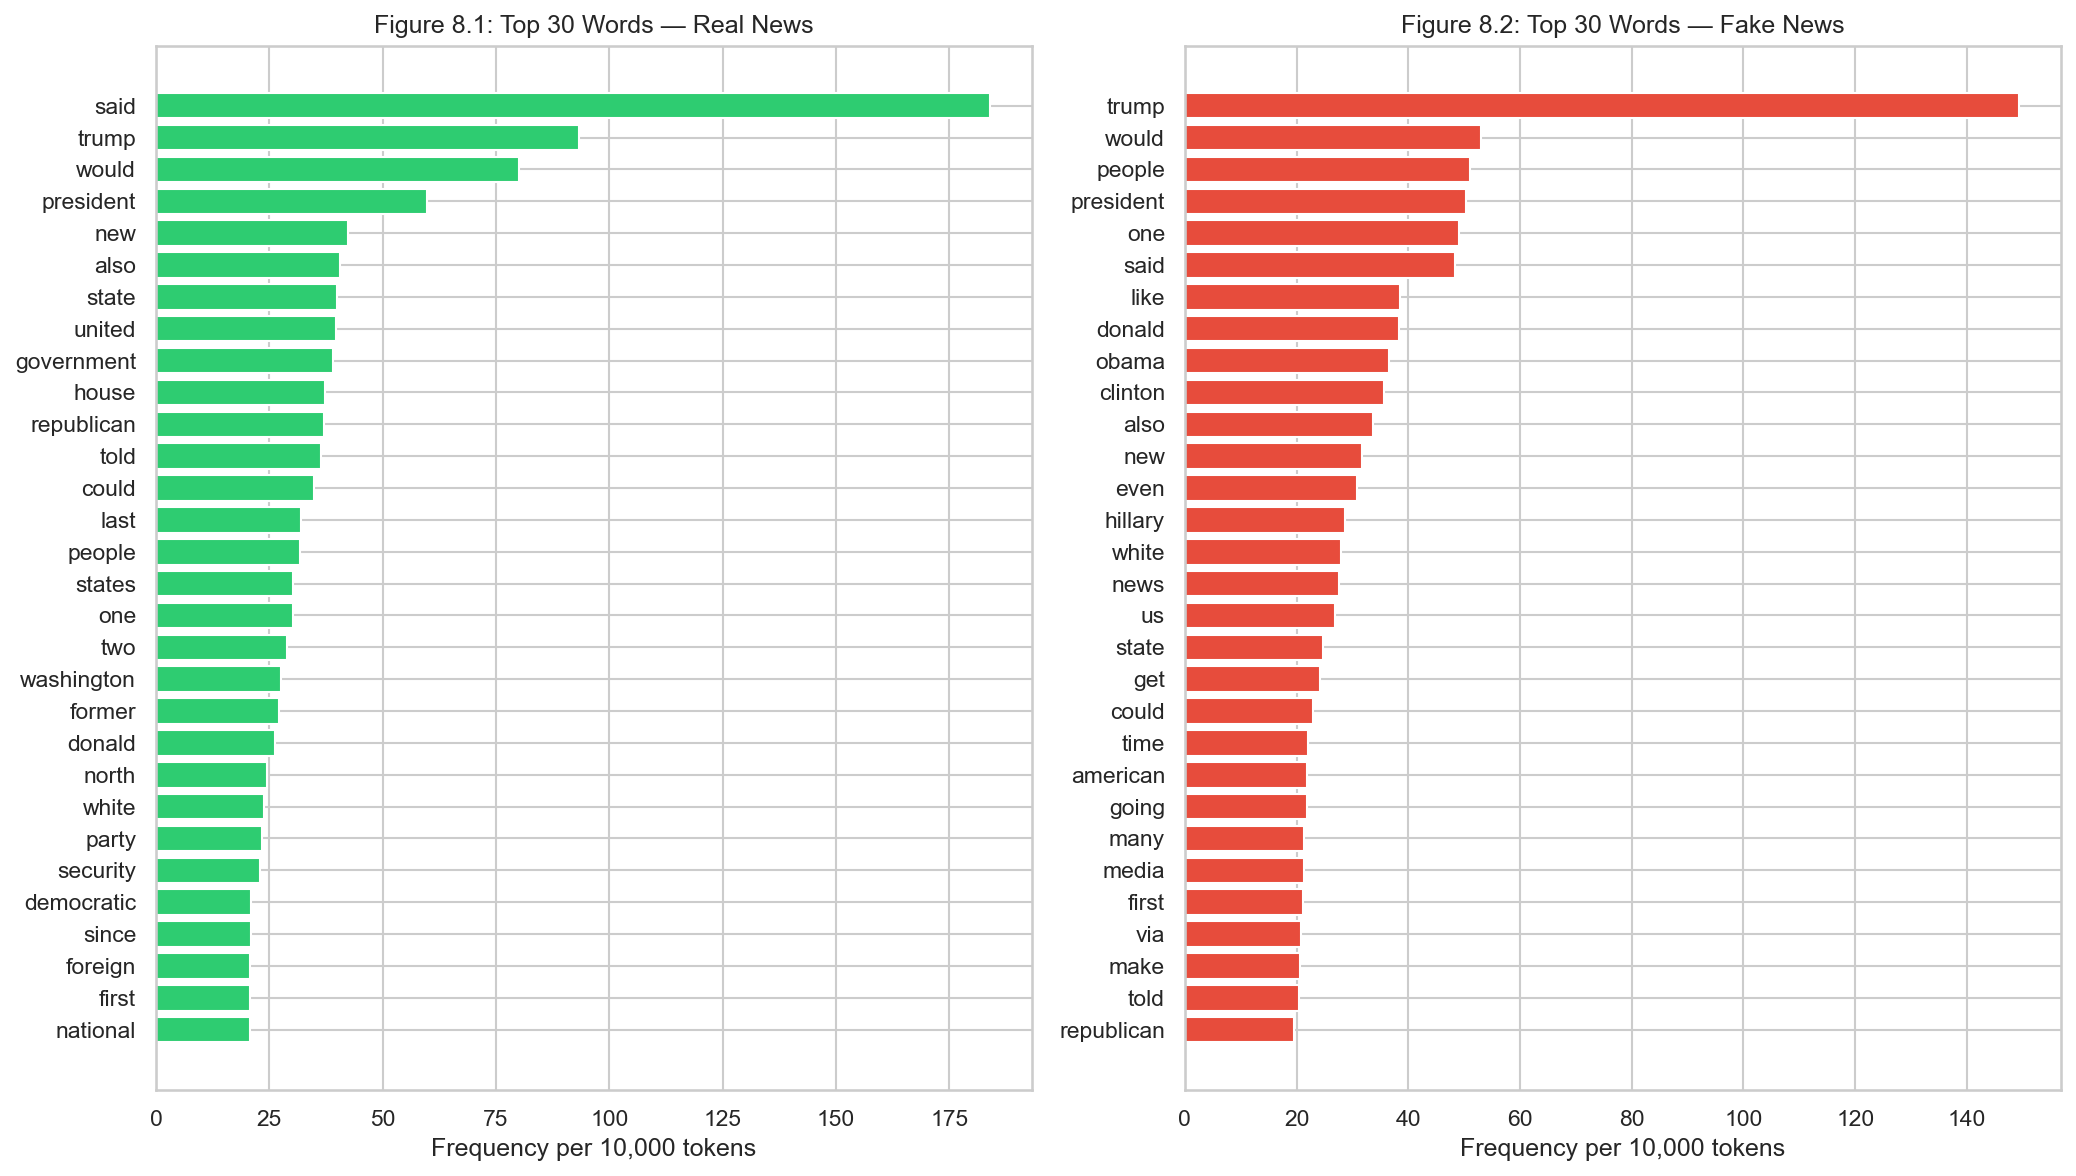

In [54]:
n = 30
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

real_top = real_freq.most_common(n)
fake_top = fake_freq.most_common(n)

# Normalize to relative frequency (per 10,000 tokens)
real_total = sum(real_freq.values())
fake_total = sum(fake_freq.values())

real_words = [w for w, _ in real_top][::-1]
real_rates = [c / real_total * 10_000 for _, c in real_top][::-1]

fake_words = [w for w, _ in fake_top][::-1]
fake_rates = [c / fake_total * 10_000 for _, c in fake_top][::-1]

ax1.barh(real_words, real_rates, color=LABEL_COLORS[1])
ax1.set_title(f"Figure 8.1: Top {n} Words — Real News")
ax1.set_xlabel("Frequency per 10,000 tokens")

ax2.barh(fake_words, fake_rates, color=LABEL_COLORS[0])
ax2.set_title(f"Figure 8.2: Top {n} Words — Fake News")
ax2.set_xlabel("Frequency per 10,000 tokens")

plt.tight_layout()
plt.show()

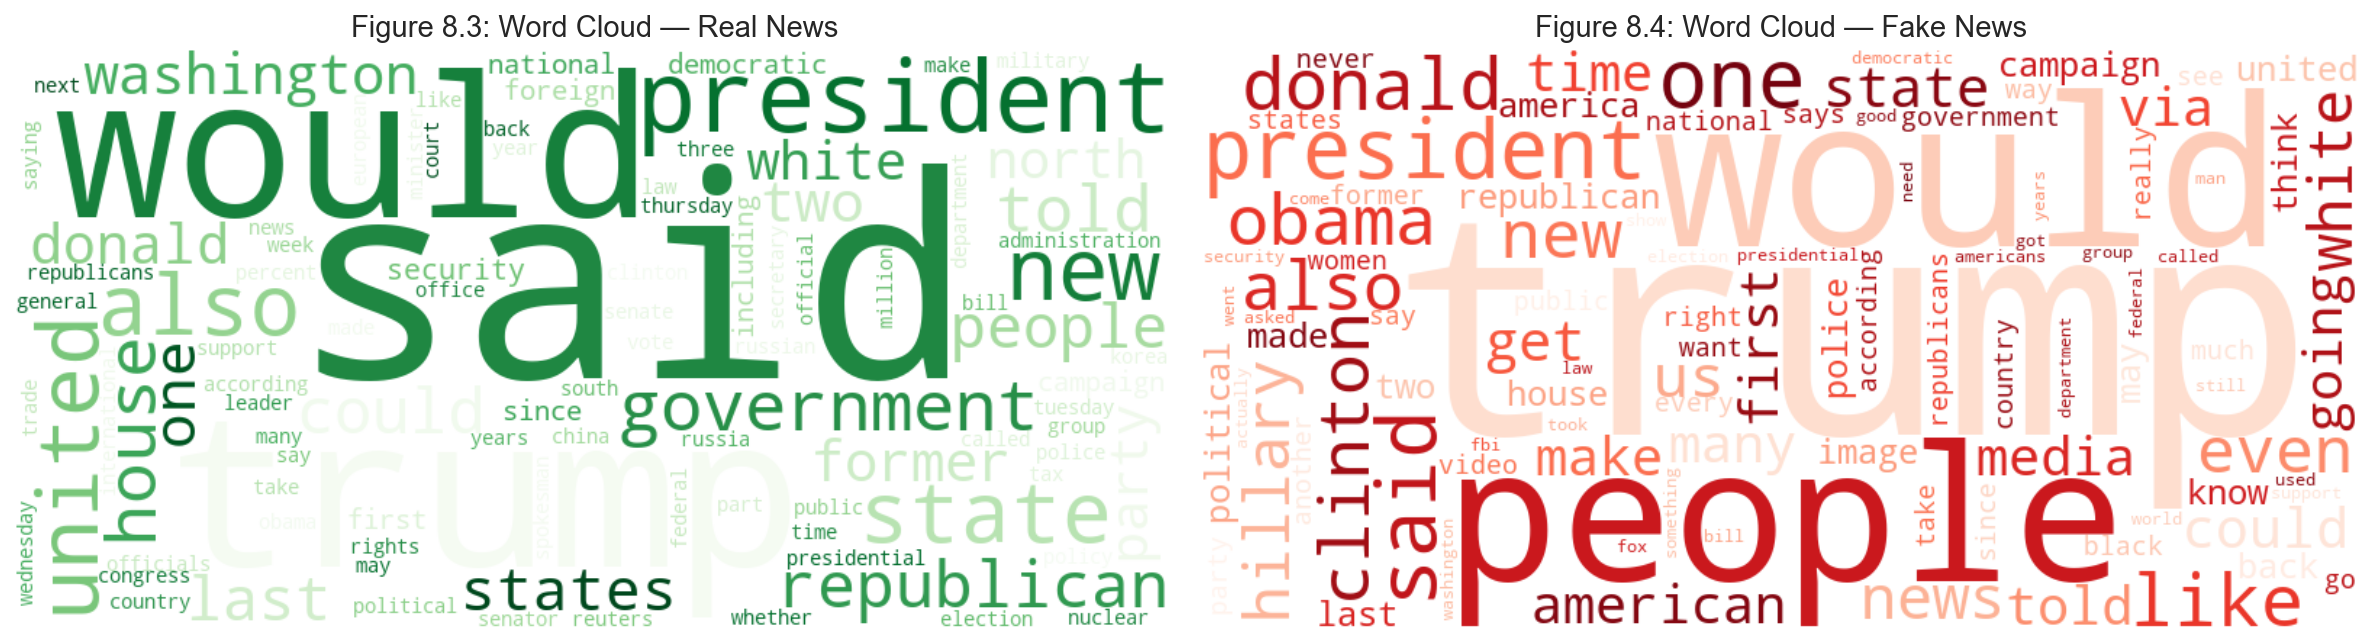

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

wc_real = WordCloud(width=800, height=400, background_color="white",
                    colormap="Greens", max_words=100)
wc_fake = WordCloud(width=800, height=400, background_color="white",
                    colormap="Reds", max_words=100)

ax1.imshow(wc_real.generate_from_frequencies(real_freq), interpolation="bilinear")
ax1.set_title("Figure 8.3: Word Cloud — Real News", fontsize=14)
ax1.axis("off")

ax2.imshow(wc_fake.generate_from_frequencies(fake_freq), interpolation="bilinear")
ax2.set_title("Figure 8.4: Word Cloud — Fake News", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.show()

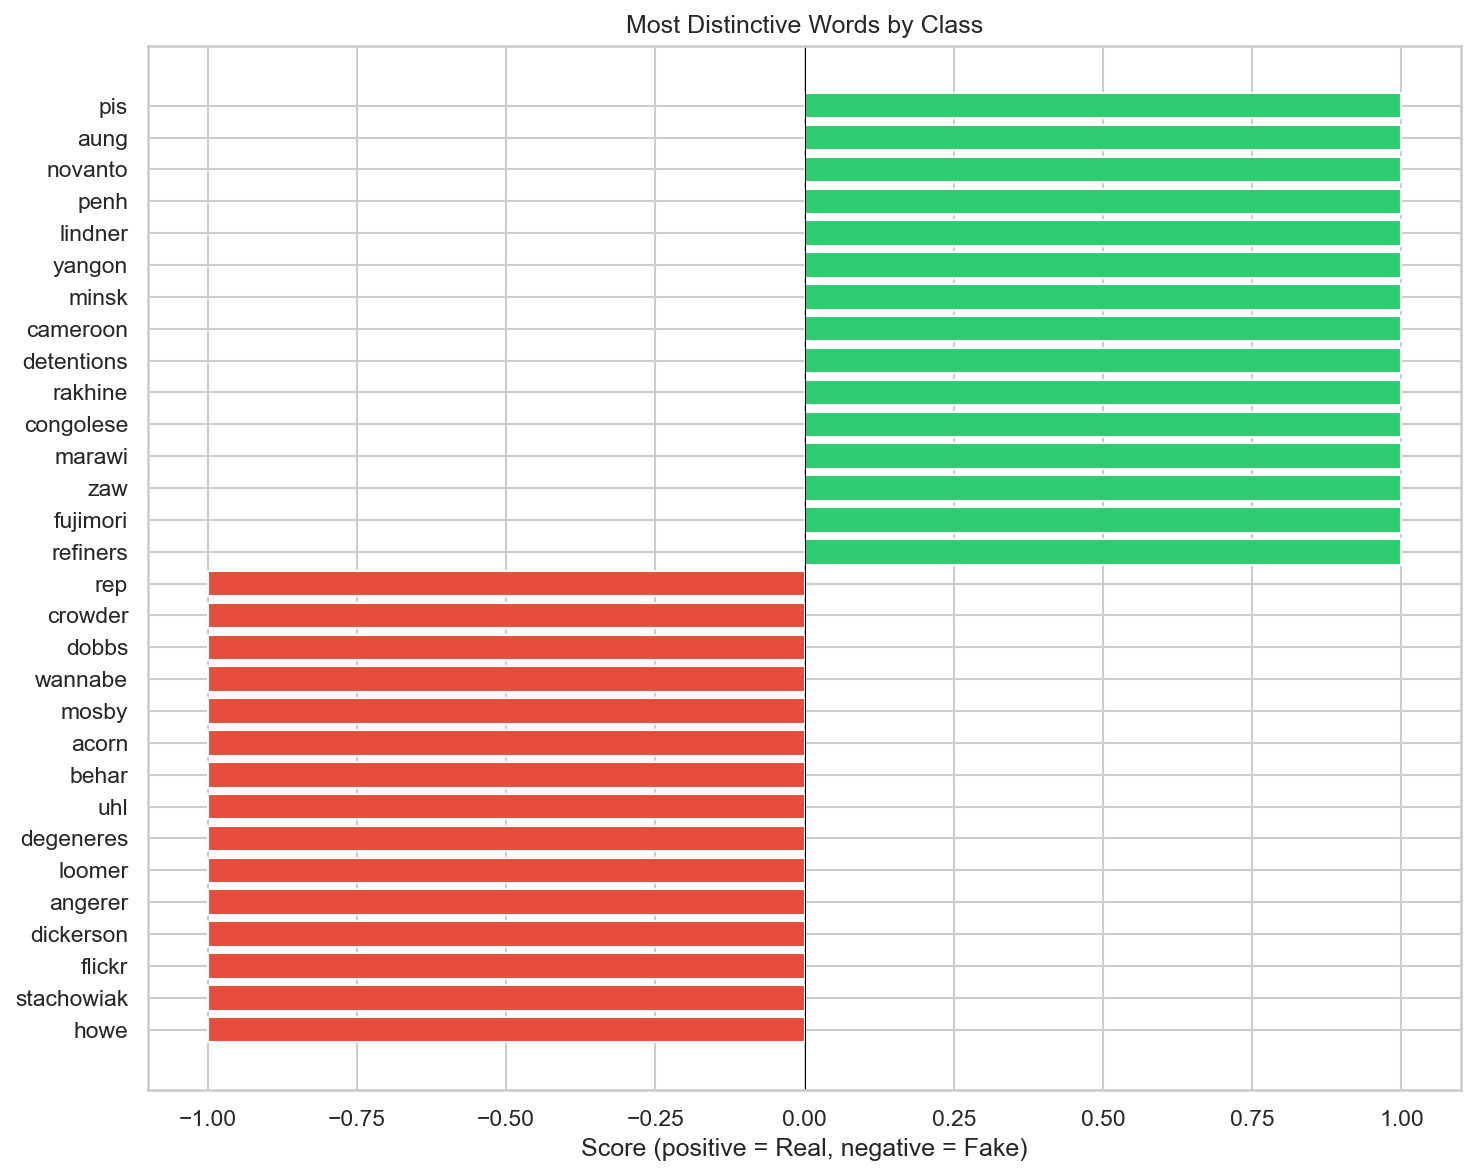

In [56]:
all_words = set(real_freq.keys()) | set(fake_freq.keys())
total_real = sum(real_freq.values())
total_fake = sum(fake_freq.values())

distinctiveness = []
for word in all_words:
    rf = real_freq.get(word, 0) / total_real
    ff = fake_freq.get(word, 0) / total_fake
    if rf + ff > 0:
        score = (rf - ff) / (rf + ff)
        total = real_freq.get(word, 0) + fake_freq.get(word, 0)
        if total >= 50:
            distinctiveness.append((word, score, total))

dist_df = pd.DataFrame(distinctiveness, columns=["word", "score", "total"])
most_real = dist_df.nlargest(15, "score")
most_fake = dist_df.nsmallest(15, "score")
plot_df = pd.concat([most_real, most_fake]).sort_values("score")

fig, ax = plt.subplots(figsize=(10, 8))
colors = [LABEL_COLORS[1] if s > 0 else LABEL_COLORS[0] for s in plot_df["score"]]
ax.barh(plot_df["word"], plot_df["score"], color=colors)
ax.set_title("Most Distinctive Words by Class")
ax.set_xlabel("Score (positive = Real, negative = Fake)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Bigram and Trigram Analysis

N-grams capture multi-word patterns that reveal writing style differences (e.g. "according to" in real news vs "you won't believe" in fake).

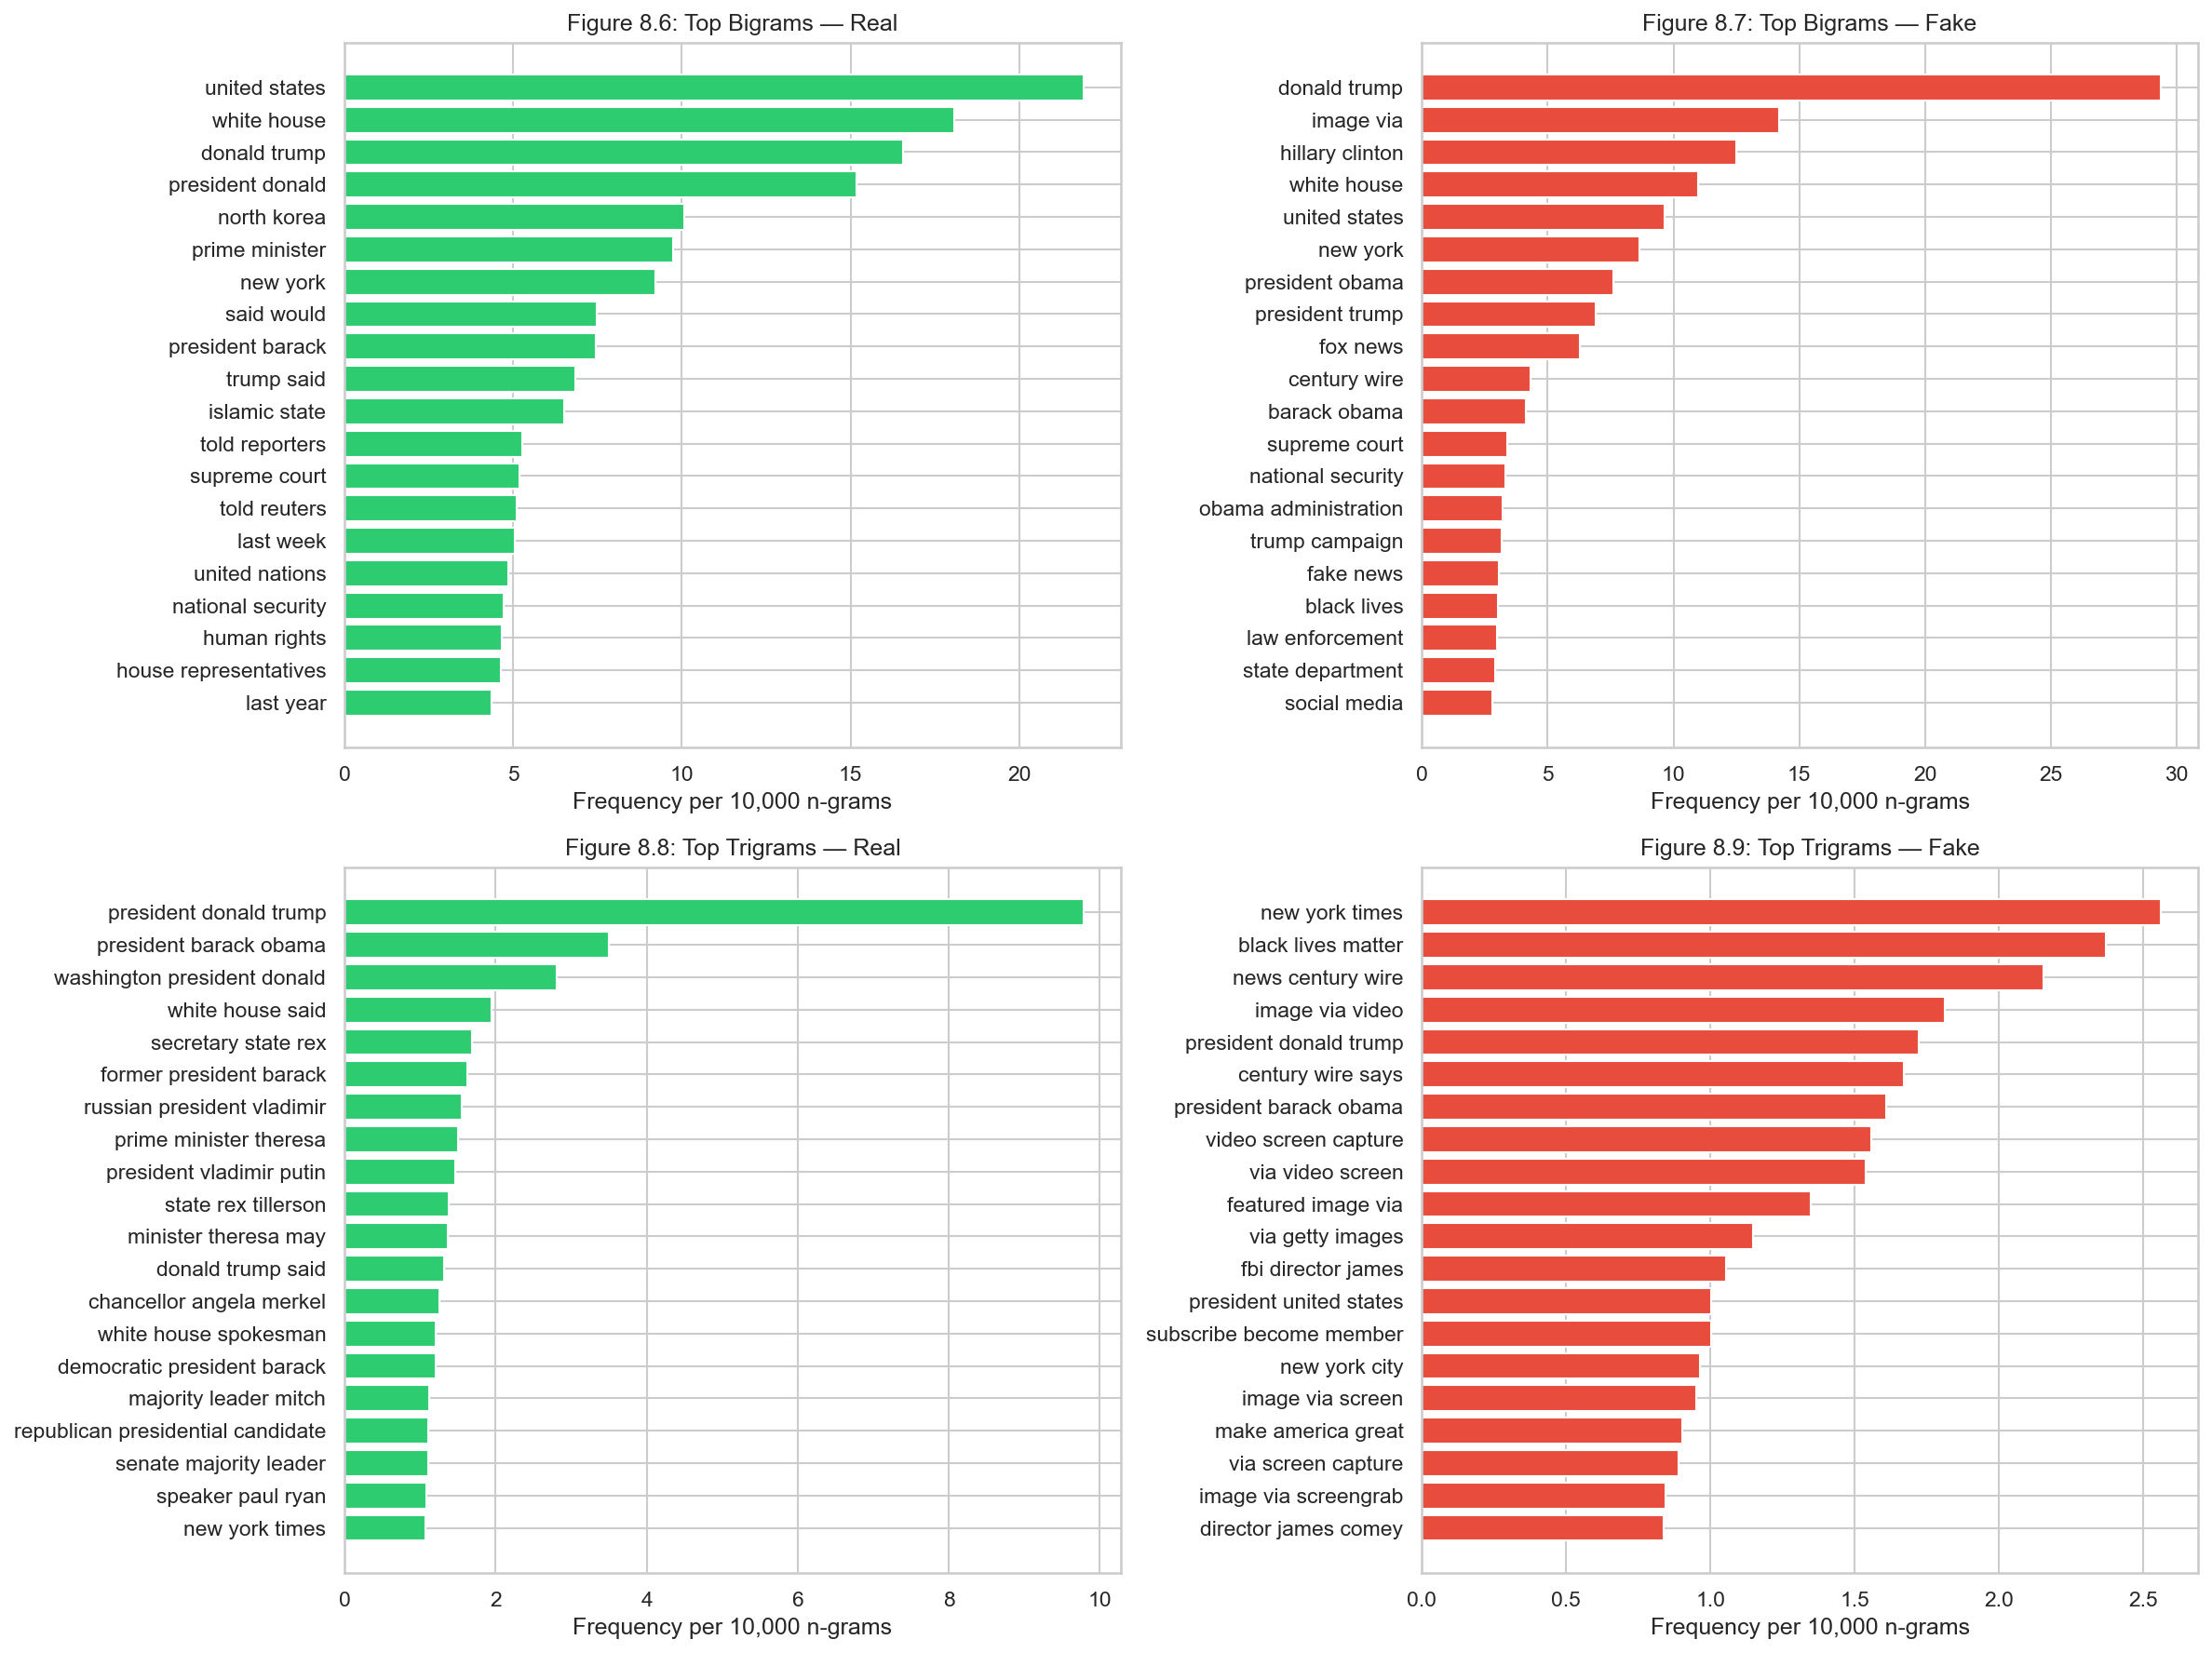

In [57]:
def get_ngram_freq(texts, n=2):
    ngrams = []
    for text in texts.dropna():
        tokens = [t for t in text.lower().split() if t.isalpha() and t not in stop_words]
        ngrams.extend(zip(*[tokens[i:] for i in range(n)]))
    return Counter([" ".join(ng) for ng in ngrams])

real_bigrams = get_ngram_freq(news_df[news_df["label"] == 1]["text"], n=2)
fake_bigrams = get_ngram_freq(news_df[news_df["label"] == 0]["text"], n=2)

real_trigrams = get_ngram_freq(news_df[news_df["label"] == 1]["text"], n=3)
fake_trigrams = get_ngram_freq(news_df[news_df["label"] == 0]["text"], n=3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
top_n = 20

for ax, freq, title, color in [
    (axes[0, 0], real_bigrams, "Figure 8.6: Top Bigrams — Real", LABEL_COLORS[1]),
    (axes[0, 1], fake_bigrams, "Figure 8.7: Top Bigrams — Fake", LABEL_COLORS[0]),
    (axes[1, 0], real_trigrams, "Figure 8.8: Top Trigrams — Real", LABEL_COLORS[1]),
    (axes[1, 1], fake_trigrams, "Figure 8.9: Top Trigrams — Fake", LABEL_COLORS[0]),
]:
    top = freq.most_common(top_n)
    total = sum(freq.values())
    words = [w for w, _ in top][::-1]
    rates = [c / total * 10_000 for _, c in top][::-1]
    ax.barh(words, rates, color=color)
    ax.set_title(title)
    ax.set_xlabel("Frequency per 10,000 n-grams")

plt.tight_layout()
plt.show()

## 9. Vocabulary Analysis

Vocabulary sizes:
  Real: 53,406
  Fake: 62,140
  Overlap: 33,168
  Real-only: 20,238
  Fake-only: 28,972
  Total unique words: 82,378


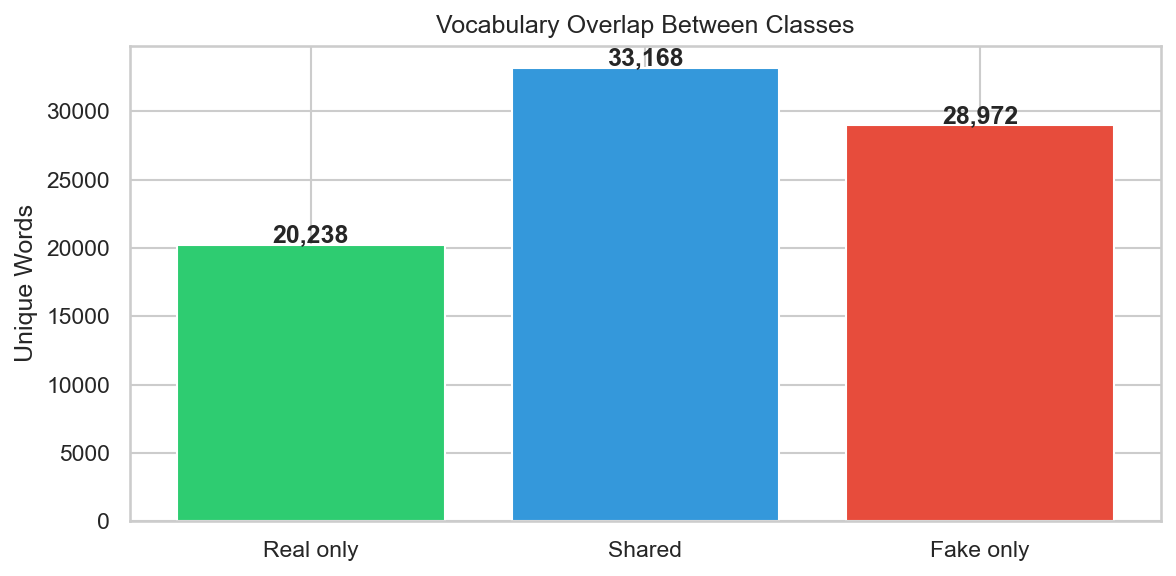

In [58]:
real_vocab = set(real_freq.keys())
fake_vocab = set(fake_freq.keys())
overlap = real_vocab & fake_vocab
real_only = real_vocab - fake_vocab
fake_only = fake_vocab - real_vocab

print(f"Vocabulary sizes:")
print(f"  Real: {len(real_vocab):,}")
print(f"  Fake: {len(fake_vocab):,}")
print(f"  Overlap: {len(overlap):,}")
print(f"  Real-only: {len(real_only):,}")
print(f"  Fake-only: {len(fake_only):,}")
print(f"  Total unique words: {len(real_vocab | fake_vocab):,}")

fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Real only", "Shared", "Fake only"]
values = [len(real_only), len(overlap), len(fake_only)]
colors_bar = [LABEL_COLORS[1], "#3498db", LABEL_COLORS[0]]
bars = ax.bar(categories, values, color=colors_bar)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{val:,}", ha="center", fontweight="bold")
ax.set_title("Vocabulary Overlap Between Classes")
ax.set_ylabel("Unique Words")
plt.tight_layout()
plt.show()

In [59]:
real_hapax = sum(1 for w, c in real_freq.items() if c == 1)
fake_hapax = sum(1 for w, c in fake_freq.items() if c == 1)

real_ttr = len(real_vocab) / sum(real_freq.values())
fake_ttr = len(fake_vocab) / sum(fake_freq.values())

metrics = pd.DataFrame({
    "Metric": ["Hapax legomena (words appearing once)", "Hapax % of vocabulary",
               "Type-Token Ratio (lexical diversity)"],
    "Real": [f"{real_hapax:,}", f"{real_hapax / len(real_vocab) * 100:.1f}%", f"{real_ttr:.4f}"],
    "Fake": [f"{fake_hapax:,}", f"{fake_hapax / len(fake_vocab) * 100:.1f}%", f"{fake_ttr:.4f}"],
})
print("Vocabulary diversity metrics:")
display(metrics.set_index("Metric"))

Vocabulary diversity metrics:


,Real,Fake
Metric,,
Hapax legomena (words appearing once),"15,944","13,874"
Hapax % of vocabulary,29.9%,22.3%
Type-Token Ratio (lexical diversity),0.0136,0.0142


### GloVe Vocabulary Coverage

Since the model will use GloVe 300d embeddings, we need to check what percentage of our vocabulary is covered. Words not in GloVe receive zero/random vectors, which degrades model performance.

Download GloVe 6B from https://nlp.stanford.edu/projects/glove/ and place `glove.6B.300d.txt` in `data/glove/`.

In [60]:
import os

glove_path = "../../data/glove/glove.6B.300d.txt"

if os.path.exists(glove_path):
    glove_vocab = set()
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            glove_vocab.add(line.split(" ", 1)[0])
    print(f"GloVe 6B 300d vocabulary size: {len(glove_vocab):,}")

    full_vocab = real_vocab | fake_vocab
    covered = full_vocab & glove_vocab
    oov = full_vocab - glove_vocab
    print(f"\nCorpus vocabulary: {len(full_vocab):,}")
    print(f"Covered by GloVe: {len(covered):,} ({len(covered)/len(full_vocab)*100:.1f}%)")
    print(f"Out-of-vocabulary: {len(oov):,} ({len(oov)/len(full_vocab)*100:.1f}%)")

    # OOV by class
    real_oov = real_vocab - glove_vocab
    fake_oov = fake_vocab - glove_vocab
    print(f"\nOOV rate — Real: {len(real_oov):,}/{len(real_vocab):,} ({len(real_oov)/len(real_vocab)*100:.1f}%)")
    print(f"OOV rate — Fake: {len(fake_oov):,}/{len(fake_vocab):,} ({len(fake_oov)/len(fake_vocab)*100:.1f}%)")

    # Token-weighted OOV (how many actual tokens are OOV, not just unique words)
    real_oov_tokens = sum(c for w, c in real_freq.items() if w not in glove_vocab)
    fake_oov_tokens = sum(c for w, c in fake_freq.items() if w not in glove_vocab)
    print(f"\nToken-weighted OOV — Real: {real_oov_tokens/sum(real_freq.values())*100:.2f}%")
    print(f"Token-weighted OOV — Fake: {fake_oov_tokens/sum(fake_freq.values())*100:.2f}%")

    print(f"\nSample OOV words: {sorted(oov, key=lambda w: real_freq.get(w, 0) + fake_freq.get(w, 0), reverse=True)[:20]}")
else:
    print(f"GloVe file not found at {glove_path}")
    print("Download from https://nlp.stanford.edu/projects/glove/ and place glove.6B.300d.txt in data/glove/")
    print("Skipping GloVe coverage analysis.")

GloVe file not found at ../../data/glove/glove.6B.300d.txt
Download from https://nlp.stanford.edu/projects/glove/ and place glove.6B.300d.txt in data/glove/
Skipping GloVe coverage analysis.


## 10. Summary & Preprocessing Recommendations

### Key Findings

| # | Finding | Preprocessing Action | Impact |
|---|---------|---------------------|--------|
| 1 | 6,251 duplicate rows (13.9%) | `drop_duplicates()` | 44,898 → 38,647 rows |
| 2 | Empty/near-empty text rows | Remove rows with empty text | Cleaner training data |
| 3 | 21,030 articles with `(Reuters)` marker — almost all in real class | `str.replace(r"\(Reuters\)", "")` | **Prevent data leakage** |
| 4 | City dateline prefixes (e.g. "WASHINGTON - ") only in real class | Strip `^[A-Z]+ - ` prefix | Prevent residual leakage |
| 5 | Excessive/inconsistent whitespace | `re.sub(r"\s+", " ", text)` | Normalize spacing |
| 6 | Single-character word artifacts | `re.sub(r"\s+[a-zA-Z]\s+", " ", text)` | Cleaner tokenization |
| 7 | Mixed case throughout | `.lower()` | Normalize vocabulary |

### Resolved Design Decisions

**Dateline prefix removal — YES, strip it.** The analysis in Section 7 shows that all-caps city dateline prefixes appear almost exclusively in real articles. After removing `(Reuters)`, patterns like `WASHINGTON - ` remain as a residual class separator. The preprocessing pipeline should strip the full dateline prefix `^[A-Z][A-Z /]+(Reuters)?\s*-\s*` to eliminate this leakage vector.

**URL removal — NO, keep URLs.** The structural patterns analysis shows that URL presence differs between classes, but URLs carry genuine content signal (fake news often links to specific sites). Removing URLs would discard potentially useful information. The model should learn to handle them.

**Single-character removal aggressiveness.** The regex `\s+[a-zA-Z]\s+` removes "I" and "a" along with artifacts. This is an acceptable trade-off: these words have minimal discriminative power for fake vs real classification, and GloVe embeddings for single characters carry little semantic information. The benefit of removing noise artifacts outweighs losing these low-information tokens.

**Stemming/lemmatization — NO.** GloVe embeddings are trained on raw word forms, not stems or lemmas. Stemming would create tokens (e.g., "investig", "polit") that have no corresponding GloVe vector, significantly increasing the OOV rate. Since we use pre-trained embeddings, we preserve original word forms.

**Minimum length threshold — YES, consider dropping.** Articles with fewer than ~5 words provide insufficient signal for a sequence model. These should be dropped after other preprocessing steps.

### Preprocessing Pipeline (recommended order)

1. Drop duplicates
2. Remove `(Reuters)` markers
3. Strip city dateline prefix (`^[A-Z][A-Z /]+\s*-\s*`)
4. Collapse whitespace (`\s+` → single space)
5. Remove single-character words
6. Convert to lowercase
7. Drop empty/near-empty rows

These findings directly inform the preprocessing pipeline implemented in `02_preprocessing.ipynb`.